<div>
<div style="font-size: 0.85em; letter-spacing: 0.08em; text-transform: uppercase; color: #1c4ed8; font-weight: 700; margin-bottom: 0.5em;">ML Research &middot; International Day Pass Pricing</div>
<h1 style="margin: 0 0 0.3em; font-weight: 800; letter-spacing: -0.01em;">From customer response models to a price recommendation</h1>
<p style="margin-top: 0; font-size: 1.2em; color: #444;">Estimating the 12-month revenue effect of a proposed international roaming price increase</p>
</div>


<div style="border: 2px solid #a94442; padding: 20px 30px;">
<h2>Disclosure</h2>
<ul style="margin-left: 0; padding-left: 1.25em;">
<li>This notebook reconstructs the methodology used in a client engagement for portfolio purposes. It does not reproduce the engagement or its results.</li>
<li>The &#36;100 million contribution described in the Introduction provides business context and is not a modeled result.</li>
<li>All data and modeled results are synthetic. The approximately 50,000-account customer base was designed to support the same type of modeling methodology. All coefficients, distributions, revenue estimates, and segment profiles are derived from synthetic data and do not reflect the engagement’s actual findings.</li>
<li>The actual findings, production Power BI deliverable, and client-identifying details are proprietary and are not reproduced here.</li>
<li>What remains faithful to the original work is the methodology, including the model architecture, estimation choices, simulation design, and segmentation logic.</li>
</ul>
</div>


<hr>
<div>
<h2>Abstract</h2>
<ul style="margin-left: 0; padding-left: 1.25em;">
<li>This study evaluates a proposed international roaming price increase using a synthetic book of approximately 50,000 accounts. It estimates the resulting 12-month roaming revenue and identifies the customers most likely to reduce or stop purchasing roaming coverage.</li>
<li>Two machine-learning models estimate how customers respond to price. The first predicts whether a trip receives no, partial, or full coverage, while the second estimates how much coverage is purchased when a customer reduces usage. A simulation then evaluates revenue across a range of prices and economic conditions.</li>
<li>The recommendation is read directly from the as-fitted models, the study's expected-case output, with no sensitivity adjustment. The study separately runs a joint stronger-response sensitivity as a disclosed robustness check, not as the basis for the price decision, because two diagnostics suggest the fitted models may understate both price response and reduction depth.</li>
<li>Account segments respond differently enough that letting each take its own best price beats a single uniform increase by roughly &#36;79,000 a year in modeled gross revenue, chiefly by holding the most price-sensitive segments near the standard price. That figure carries no implementation or fairness cost, so segmentation informs the pricing decision more than it settles it, while also showing where retention effort belongs.</li>
<li>Under the as-fitted model, modeled 12-month roaming revenue is still rising at the top of the evaluated range. The recommendation is therefore a <strong>20% increase</strong>, the highest price the study evaluated: it describes the best price within the study's permitted range, not a proven unconstrained optimum. Under the joint stronger-response sensitivity robustness check, the same curve instead peaks at 15%; that result is disclosed as a limitation rather than incorporated into the price selection.</li>
<li>Because the synthetic book is a small illustrative sample, its modeled dollar figures are also scaled against an independent, real-world anchor (U.S. Department of Commerce international air-travel statistics) under a disclosed 30% assumed carrier market share. At the recommended price, that scale-up lands at roughly &#36;102 million against the &#36;100 million company-wide target the study was assigned (Section 5.1).</li>
<li>The results are packaged as a Power BI-ready star schema (precomputed tables, relationships, and measure definitions), so a scenario model over price, customer mix, and economic conditions can be built from the study outputs without rerunning it.</li>
</ul>
</div>

<hr>
<div>
<h2>Introduction</h2>
<p><strong>Business Question:</strong> International roaming was assigned a &#36;100 million contribution toward closing a larger company-wide revenue gap. How much of that target could be delivered through a price change, and how would different customer groups be affected?</p>
<p><strong>Data and Scope:</strong> The study uses a synthetic customer base of approximately 50,000 accounts, built and validated in a separate data notebook. It estimates the effect on roaming revenue over 12 months. Wireless churn (customers leaving the carrier entirely) is outside the scope of this study; the results describe roaming-pass revenue, not total customer value.</p>
<p><strong>Study Design:</strong> The study follows four connected stages, with each stage supplying the information required by the next.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Section</th>
<th style="text-align: left;">Business Question Answered</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;">01 · Customer Response (State Model)</td>
<td style="text-align: left;">How likely is a customer to choose no, partial, or full roaming coverage for a trip at each candidate price?</td>
</tr>
<tr>
<td style="text-align: left;">02 · Purchase Amount (Magnitude Model)</td>
<td style="text-align: left;">When a customer chooses partial coverage, how much roaming coverage will be purchased?</td>
</tr>
<tr>
<td style="text-align: left;">03 · 12-Month Revenue Simulation</td>
<td style="text-align: left;">How much 12-month roaming revenue could result at each price under different economic and market conditions, under both the fitted models and the joint stronger-response sensitivity?</td>
</tr>
<tr>
<td style="text-align: left;">04 · Customer Segments and Delivery</td>
<td style="text-align: left;">Which customer groups are most affected, and how are the results packaged for a downstream Power BI scenario model?</td>
</tr>
</tbody>
</table>
<p><strong>Model Requirements:</strong> Because the predicted probabilities enter directly into the revenue calculation, they must be well calibrated, not merely useful for ranking customers. The price-response curves must also be monotonic and smooth, ensuring that simulated customer behavior remains economically coherent across the full range of candidate prices.</p>
</div>


<hr>
<div>
<h2>Initialize Environment</h2>
<p>Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout the study. Each section then loads only the data and defines only the components it requires.</p>
</div>


In [1]:
# Standard Library
from pathlib import Path

# Numerical and Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Scikit-Learn: Models
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

# Scikit-Learn: Preprocessing and Calibration
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Scikit-Learn: Metrics
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    silhouette_score,
)

# Jupyter
from IPython.display import display


In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
PALETTE = [ACCENT, '#17369b', '#6f8fe8', RED, MUTED, INK]

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

# Shared Table Styles
TABLE_STYLES = [
    {
        'selector': 'caption',
        'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '8px'),
        ],
    },
    {
        'selector': 'th',
        'props': [('text-align', 'left !important')],
    },
    {
        'selector': 'td',
        'props': [('text-align', 'left !important')],
    },
]

In [3]:
# Data Loading and Export Helpers
DATA = Path('data/synthetic')

def load(name):
    
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    
    if csv.exists():
        return pd.read_csv(csv)
    
    raise FileNotFoundError(
        f'{name} not found in {DATA.resolve()}. Run '
        'data/00_generate_and_validate_data.ipynb, then the earlier sections, first.')

    
def _parquet_available():
    
    for mod in ('pyarrow', 'fastparquet'):
        try:
            __import__(mod)
            return True
        
        except ImportError:
            continue
            
    print('pyarrow/fastparquet not found; writing CSV instead.')
    
    return False


FMT = 'parquet' if _parquet_available() else 'csv'

def save_tables(frames, dest = DATA, with_cols = False):
    
    dest = Path(dest)
    dest.mkdir(parents = True, exist_ok = True)
    
    names, rows, cols = [], [], []
    for name, df in frames.items():
        path = dest / f'{name}.{FMT}'
        df.to_parquet(path, index = False) if FMT == 'parquet' else df.to_csv(path, index = False)
        names.append(path.name)
        rows.append(len(df))
        cols.append(df.shape[1])
        
    data = {'rows': rows, 'cols': cols} if with_cols else {'rows': rows}
    
    return pd.DataFrame(data, index = names).rename_axis(None)


In [4]:
# Domain Constants and Data-Preparation Helpers
CLASSES = ['null', 'partial', 'full']
IDX = {c: i for i, c in enumerate(CLASSES)}
DAY_THRESH = 0.70
PRICE_FIRST, PRICE_ADDL = 10.0, 5.0


def reconstruct_label(df, day_thresh = DAY_THRESH):

    ratio = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower = 1)

    y = pd.Series('full', index = df.index, dtype = object)
    y[(ratio < day_thresh) | (lines < 0.999)] = 'partial'
    y[df['days_bought'] == 0] = 'null'

    return y


def build_features(df):

    out = pd.DataFrame(index = df.index)
    out['is_business'] = df['is_business'].astype(int)
    out['lines_on_account'] = df['lines_on_account']
    out['tenure_months'] = df['tenure_months']
    out['premium'] = (df['plan_tier'] == 'premium').astype(int)
    out['value_tier'] = (df['plan_tier'] == 'value').astype(int)
    
    for r in ['asia', 'caribbean', 'central_america', 'europe', 'mideast', 'oceania', 'south_america']:  # Basline: Africa
        out[f'region_{r}'] = (df['region'] == r).astype(int)

    out['month_of_year'] = df['month'] % 12
    out['macro_index'] = df['macro_index']

    return out


def prior_trip_count(df):

    hist = df[['account_id', 'month']].sort_values(['account_id', 'month'])
    cum = hist.groupby('account_id').cumcount()
    same = hist.groupby(['account_id', 'month']).cumcount()

    return (cum - same).reindex(df.index).fillna(0).astype(int)


def load_trips(with_macro = True):

    t = load('trips').merge(load('accounts'), on = 'account_id', how = 'left')

    if with_macro:
        t = t.merge(load('macro')[['month', 'macro_index']], on = 'month', how = 'left')

    return t


In [5]:
# Probability and Price-Shift Helpers
_SORTED_CLASSES = sorted(CLASSES)
_PERM = [CLASSES.index(c) for c in _SORTED_CLASSES]


def LL(y_true, P):
    
    return log_loss(y_true, P[:, _PERM], labels = _SORTED_CLASSES)


def softmax(eta):
    
    e = np.exp(eta - eta.max(axis = 1, keepdims = True))
    
    return e / e.sum(axis=1, keepdims = True)


def logp(p):
    
    return np.log(np.clip(p, 1e-9, 1.0))


def price_shift_logodds(sweep, mult, ref = 1.0):
    
    idx = sweep.index.to_numpy()
    tgt = sweep.iloc[np.argmin(np.abs(idx - mult))][CLASSES].to_numpy()
    base = sweep.iloc[np.argmin(np.abs(idx - ref))][CLASSES].to_numpy()
    
    return logp(tgt) - logp(base)


def apply_price_shift(P0, shift, response_scale = 1.0):
    
    return softmax(logp(P0) + response_scale * shift)


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>01 · The State Model</h1>
<p><strong>Purpose:</strong> Predicts, for each customer trip and candidate price, the probability distribution across three coverage levels: null, partial, and full. Because these probabilities enter directly into the revenue calculation, they must be well calibrated. A predicted 15% probability of partial coverage should correspond to approximately 15% of comparable trips receiving partial coverage.</p>
<p><strong>Architecture:</strong> The model has two stages. Stage 1 estimates baseline state probabilities at the standard price using customer and trip characteristics other than price, including travel behavior, number of lines, plan tier, tenure, region, and time of year. Stage 2 adds a constrained price component that estimates how those probabilities change as price rises or falls. This produces smooth, monotonic price-response curves across the candidate range, including intermediate prices not previously charged.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Stage</th>
<th style="text-align: left;">Method</th>
<th style="text-align: left;">Reasoning</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">1</td>
<td style="text-align: left; vertical-align: top;">Gradient-Boosted Trees on Non-Price Features</td>
<td style="text-align: left; vertical-align: top;">Customer behavior is nonlinear and includes many interactions, making a flexible tree model appropriate. At this stage, predictive flexibility is more important than coefficient-level interpretation.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">2</td>
<td style="text-align: left; vertical-align: top;">Multinomial Logit with Stage 1 as a Fixed Offset</td>
<td style="text-align: left; vertical-align: top;">The price response must remain smooth and monotonic across the candidate range. A sign-constrained parametric price component provides that structure, while a tree alone does not.</td>
</tr>
</tbody>
</table>
<p><strong>Design Requirements:</strong> Because the model feeds a forward-looking revenue simulation, its outputs must be statistically reliable and economically coherent. The following requirements govern how labels are constructed, data is split, probabilities are calibrated, the price effect is estimated, and the response is tested beyond the original market-test regions.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Requirement</th>
<th style="text-align: left;">Where</th>
<th style="text-align: left;">Reasoning</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Labels Reconstructed from Observed Data</td>
<td style="text-align: left; vertical-align: top;">Label Construction</td>
<td style="text-align: left; vertical-align: top;">The behavioral state is not recorded and must be derived from observed trip quantities, including days and lines purchased relative to days and lines traveled.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Time-Based Split</td>
<td style="text-align: left; vertical-align: top;">Train, Calibration, and Test Split</td>
<td style="text-align: left; vertical-align: top;">The model is used to forecast future behavior, so training, calibration, and testing are separated in time. A random split could allow future patterns to influence model development and overstate performance.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Calibrated Probabilities</td>
<td style="text-align: left; vertical-align: top;">Final Probability Model</td>
<td style="text-align: left; vertical-align: top;">The revenue calculation multiplies each probability by a dollar value, so probabilities must be accurate in level, not merely useful for ranking customers.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Price Effect Separated from Other Factors</td>
<td style="text-align: left; vertical-align: top;">Price Identification and Stage 2</td>
<td style="text-align: left; vertical-align: top;">Historical price changes were not assigned randomly. The price relationship must therefore be estimated after accounting for factors such as customer characteristics, region, and season.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Monotonic and Smooth Price Response</td>
<td style="text-align: left; vertical-align: top;">Stage 2</td>
<td style="text-align: left; vertical-align: top;">The modeled response must move consistently in the expected direction as price changes, without implausible reversals or discontinuities.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Price-Response Transferability Tested</td>
<td style="text-align: left; vertical-align: top;">Regional Holdout</td>
<td style="text-align: left; vertical-align: top;">The price response is estimated using market-test data but applied to the full customer base, so its performance must be tested outside the original market-test regions.</td>
</tr>
</tbody>
</table>
</div>


In [6]:
# Load Trip Data
trips = load_trips()
print(f'{len(trips):,} trips \u00b7 {trips.account_id.nunique():,} accounts \u00b7 {trips.month.nunique()} months')


94,579 trips · 29,406 accounts · 24 months


<hr>
<div>
<h2>1 · Label Reconstruction</h2>
<p><strong>Purpose:</strong> Reconstructs three coverage levels from observed trip data because the underlying behavioral state is not recorded in production.</p>
<p><strong>Design Notes:</strong> Coverage level is the outcome predicted by the state model and an input to the revenue calculation. For each customer trip and candidate price, the model estimates the probability of no, partial, or full coverage. Expected revenue is then calculated by multiplying each probability by the revenue associated with that coverage level.</p>
<p style="margin-bottom: 0;">Coverage level is determined by the share of travel days covered by a pass and whether every traveling line is covered:</p>
<ul style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><code>day coverage = days_bought / days_traveled</code></li>
<li><code>line coverage = lines_active / lines_traveling</code></li>
</ul>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Level</th>
<th style="text-align: left;">Meaning</th>
<th style="text-align: left;">Rule per trip</th>
<th style="text-align: left;">Notes</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>null</code></td>
<td style="text-align: left; vertical-align: top;">No roaming pass purchased</td>
<td style="text-align: left; vertical-align: top;"><code>days_bought == 0</code></td>
<td style="text-align: left; vertical-align: top;">The customer traveled but used an alternative such as a local SIM, eSIM, Wi-Fi, or no connectivity.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>partial</code></td>
<td style="text-align: left; vertical-align: top;">Some coverage purchased, but below the full-coverage rule</td>
<td style="text-align: left; vertical-align: top;">Day coverage is below 70%, or at least one traveling line is not covered</td>
<td style="text-align: left; vertical-align: top;">May result from fewer covered days, fewer covered lines, or both.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>full</code></td>
<td style="text-align: left; vertical-align: top;">Broad trip coverage under the study’s operational definition</td>
<td style="text-align: left; vertical-align: top;">Day coverage is at least 70%, and every traveling line is covered</td>
<td style="text-align: left; vertical-align: top;">The 70% threshold defines broad trip coverage without requiring a pass for every travel day.</td>
</tr>
</tbody>
</table>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Full coverage represents 77.8% of reconstructed labels, followed by partial coverage at 12.1% and null coverage at 10.1%.</li>
<li>Because full coverage dominates the labels, calibrated probabilities and class-specific performance measures are more informative than overall classification accuracy.</li>
</ol>
</div>


In [7]:
# Reconstruct Coverage Labels
trips['y'] = reconstruct_label(trips)
y = trips['y'].to_numpy()
yi = np.array([IDX[v] for v in y])

LABEL_INPUTS = [
    'days_traveled',
    'lines_traveling',
    'days_bought',
    'lines_active',
]

LABEL_INPUTS_COMPLETE = bool(
    trips[LABEL_INPUTS].notna().all().all()
)

assert LABEL_INPUTS_COMPLETE, (
    'incomplete trip record found; synthetic data is assumed fully observed'
)

LEFT_ALIGNED_TABLE_STYLES = [
    {
        'selector': 'caption',
        'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '8px'),
        ],
    },
    {
        'selector': 'th',
        'props': [
            ('text-align', 'left !important'),
        ],
    },
    {
        'selector': 'td',
        'props': [
            ('text-align', 'left !important'),
        ],
    },
]

label_distribution = (
    trips['y']
    .value_counts()
    .reindex(CLASSES, fill_value=0)
    .rename_axis('Coverage Level')
    .reset_index(name='Trips')
)

label_distribution['Share of Trips'] = (
    label_distribution['Trips']
    / label_distribution['Trips'].sum()
)

display(
    label_distribution.style
    .hide(axis='index')
    .format({
        'Trips': '{:,.0f}',
        'Share of Trips': '{:.1%}',
    })
    .bar(
        subset=['Share of Trips'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('Reconstructed Coverage-State Distribution')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(LEFT_ALIGNED_TABLE_STYLES)
)

label_audit = pd.DataFrame({
    'Validation': ['Label inputs'],
    'Status': ['Pass'],
    'Result': [
        f'All four label inputs are complete across {len(trips):,} trip records'
    ],
})

display(
    label_audit.style
    .hide(axis='index')
    .set_caption('Coverage-Label Audit')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset=['Status'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
            'text-align': 'left',
        },
    )
    .set_table_styles(LEFT_ALIGNED_TABLE_STYLES)
)


Coverage Level,Trips,Share of Trips
null,"9,566",10.1%
partial,"11,478",12.1%
full,"73,535",77.7%


Validation,Status,Result
Label inputs,Pass,"All four label inputs are complete across 94,579 trip records"


<hr>
<div>
<h2>2 · Feature Selection and Data Audits</h2>
<p><strong>Purpose:</strong> Builds the non-price feature set for Stage 1 after auditing candidate fields for target leakage and redundant information.</p>
<p><strong>Design Notes:</strong> Stage 1 uses only information available when the prediction is made. Fields that define the outcome, become known during or after the trip, or exist only in the synthetic data are excluded from the model.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Target Leakage Audit.</strong> The following fields are excluded from the predictive feature set:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>days_bought</code> and <code>lines_active</code> help define the reconstructed coverage label.</li>
<li><code>pass_revenue</code> and <code>account_lost</code> are outcomes observed after roaming activity occurs.</li>
<li><code>state</code> is the target variable created during label reconstruction.</li>
<li><code>price_sensitivity</code> and <code>travel_propensity</code> are latent variables used to generate the synthetic data and would not be observable in production.</li>
<li><code>days_traveled</code> and <code>lines_traveling</code> are final trip outcomes: coverage is metered day by day as an account's lines connect to foreign towers, so both fields are only fully known once the trip is over, not at the point the model's prediction is used. They are retained for post-trip label construction, historical revenue calculations, and simulation exposure assumptions, but are excluded from the probability model.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Price Separation.</strong> <code>price_multiplier</code> and <code>log_price</code> are excluded from Stage 1. Price enters only in Stage 2, allowing the study to estimate a smooth and monotonic price response separately from the customer and trip characteristics captured in Stage 1.</li>
<li style="margin-bottom: 0.7em;"><strong>Redundancy Audit.</strong> <code>substitute_ease</code> is a synthetic measure of how easily customers in a region can avoid purchasing the company’s roaming pass by using alternatives such as a local SIM, eSIM, or Wi-Fi. Because it is assigned entirely from <code>region</code>, it contains no independent information.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Including both <code>substitute_ease</code> and region would duplicate the same signal.</li>
<li>Interacting <code>substitute_ease</code> with price could make regional differences in the market test appear to be a general substitution effect.</li>
<li>The field is excluded from both stages. Region remains in Stage 1, while Stage 2 estimates the price response without this deterministic regional proxy.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Historical Feature Construction.</strong> <code>prior_trips</code> uses an expanding time window. Only trips from earlier months are counted, preventing information from future trips from entering the model.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The leakage audit excludes label-defining, downstream, post-trip, and synthetic latent fields.</li>
<li><code>substitute_ease</code> is fully determined by region and is excluded as redundant.</li>
<li>Fifteen non-price features remain for the Stage 1 model.</li>
</ol>
</div>


In [8]:
# Data Audit
region_audit = (
    trips.groupby('region', as_index=False)
    .agg(
        substitute_ease=('substitute_ease', 'first'),
        distinct_values=('substitute_ease', 'nunique'),
    )
)

DETERMINISTIC = bool(region_audit['distinct_values'].eq(1).all())

trips['prior_trips'] = prior_trip_count(trips)
trips['log_price'] = np.log(trips['price_multiplier'])

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

LEAKY = {
    'days_bought', 'lines_active', 'pass_revenue', 'account_lost', 'state', 'y',
    'price_sensitivity', 'travel_propensity', 'price_multiplier', 'log_price',
    'days_traveled', 'lines_traveling', 'substitute_ease',
}

EXPECTED_COLS = [
    'is_business', 'lines_on_account', 'tenure_months', 'premium', 'value_tier',
    'region_asia', 'region_caribbean', 'region_central_america', 'region_europe',
    'region_mideast', 'region_oceania', 'region_south_america',
    'month_of_year', 'macro_index', 'prior_trips',
]

NO_LEAKAGE = not bool(set(X.columns) & LEAKY)
EXPECTED_SCHEMA = list(X.columns) == EXPECTED_COLS
FINITE_VALUES = bool(np.isfinite(X.to_numpy()).all())

assert DETERMINISTIC, 'substitute_ease varies within at least one region'
assert NO_LEAKAGE, 'leakage in the Stage 1 feature matrix'
assert EXPECTED_SCHEMA, f'unexpected Stage 1 feature set: {list(X.columns)}'
assert FINITE_VALUES, 'missing or non-finite values in the Stage 1 feature matrix'

CAPTION_STYLE = {
    'selector': 'caption',
    'props': [
        ('caption-side', 'top'),
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('text-align', 'left'),
        ('padding-bottom', '8px'),
    ],
}

region_display = region_audit.rename(columns={
    'region': 'Region',
    'substitute_ease': 'Substitute Ease',
    'distinct_values': 'Distinct Values',
})

display(
    region_display.style
    .hide(axis='index')
    .format({
        'Substitute Ease': '{:.2f}',
        'Distinct Values': '{:,.0f}',
    })
    .set_caption('Substitute Ease by Region')
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'table',
            'props': [
                ('table-layout', 'fixed'),
                ('width', '100%'),
            ],
        },
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'th.col0, td.col0',
            'props': [('width', '35%')],
        },
        {
            'selector': 'th.col1, td.col1',
            'props': [('width', '35%')],
        },
        {
            'selector': 'th.col2, td.col2',
            'props': [('width', '30%')],
        },
        {
            'selector': 'td.col1, td.col2',
            'props': [('text-align', 'right !important')],
        },
    ])
)

audit_summary = pd.DataFrame({
    'Validation': [
        'Regional mapping',
        'Feature leakage',
        'Feature schema',
        'Finite values',
    ],
    'Status': ['Pass', 'Pass', 'Pass', 'Pass'],
    'Result': [
        'One substitute-ease value per region',
        'No outcome or post-purchase variables included',
        f'All {len(EXPECTED_COLS)} expected features present',
        'No missing or non-finite feature values',
    ],
})

display(
    audit_summary.style
    .hide(axis='index')
    .set_caption('Stage 1 Data-Audit Summary')
    .set_properties(
        subset=['Status'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
        },
    )
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'th, td',
            'props': [('text-align', 'left !important')],
        },
    ])
)


Region,Substitute Ease,Distinct Values
africa,0.35,1
asia,0.75,1
caribbean,0.45,1
central_america,0.45,1
europe,0.85,1
mideast,0.55,1
oceania,0.65,1
south_america,0.55,1


Validation,Status,Result
Regional mapping,Pass,One substitute-ease value per region
Feature leakage,Pass,No outcome or post-purchase variables included
Feature schema,Pass,All 15 expected features present
Finite values,Pass,No missing or non-finite feature values


<hr>
<div>
<h2>3 · Split by Time</h2>
<p><strong>Purpose:</strong> Separates trips chronologically so predictive accuracy and probability calibration can be evaluated on later trips that the model did not use for training. Because the market price test ended in month 15, the later periods provide limited direct evidence about the price response; the regional holdout in Section 6.2 provides a complementary test.</p>
<p><strong>Synthetic-data assumption:</strong> The dataset represents a finalized historical snapshot, and all trips are treated as fully reported. Operational reporting delays are outside the scope of this portfolio study.</p>
<p><strong>Design Notes:</strong> The split preserves the order in which trips occurred. Separate temporal and regional holdouts are used because model performance over time and price-response generalization are distinct validation questions.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Chronological Slices.</strong> Months are numbered relative to the beginning of the 24-month study period. A separate calibration split allows the probability adjustment to be estimated independently while preserving the test set for an unbiased final evaluation. Calibrating on the training data could preserve the model’s in-sample overconfidence, while calibrating on the test data would contaminate the final evaluation.
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Slice</th>
<th style="text-align: left;">Months</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Train</td>
<td style="text-align: left; vertical-align: top;">0–15</td>
<td style="text-align: left; vertical-align: top;">Fit the Stage 1 and Stage 2 models</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Calibration</td>
<td style="text-align: left; vertical-align: top;">16–19</td>
<td style="text-align: left; vertical-align: top;">Fit the probability calibrator only</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Test</td>
<td style="text-align: left; vertical-align: top;">20–23</td>
<td style="text-align: left; vertical-align: top;">Conduct the final evaluation on untouched data</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Price-Response Validation Limitation.</strong> The market price test ran during months 8 through 15. The calibration and test periods contain only limited naturally occurring price variation.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The temporal test set provides a strong evaluation of general predictive accuracy and calibration over time.</li>
<li>It provides only limited direct evidence about the model’s price-response curve.</li>
<li>The regional holdout in Section 6.2 evaluates whether the price response estimated from the market-test population generalizes to the broader customer book.</li>
<li>Temporal and regional holdouts are complementary and answer different validation questions.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Evaluation Population.</strong> The split is performed by trip month rather than by account. An account may therefore appear in more than one period if it has multiple trips. This design evaluates predictions for future trips from the customer book, not generalization to an entirely new set of customers.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong> An off-standard trip is a trip observed at a price other than the standard price.</p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Train (months 0–15): 54,045 trips, 22,624 accounts, 38.7% off-standard, 5 observed price levels.</li>
<li>Calibration (months 16–19): 22,062 trips, 13,298 accounts, 38.8% off-standard, 4 observed price levels.</li>
<li>Test (months 20–23): 18,472 trips, 11,799 accounts, 10.1% off-standard, 3 observed price levels. The limited off-standard representation restricts how strongly this period can validate the price response.</li>
</ol>
</div>


In [9]:
# Time-Based Split
month = trips['month'].to_numpy()
tr = month <= 15
ca = (month >= 16) & (month <= 19)
te = month >= 20

splits = {
    'Train': ('0–15', tr),
    'Calibration': ('16–19', ca),
    'Test': ('20–23', te),
}

split_summary = pd.DataFrame([
    {
        'Sample': name,
        'Months': months,
        'Trips': mask.sum(),
        'Accounts': trips.loc[mask, 'account_id'].nunique(),
        'Off-Standard Share': trips.loc[
            mask, 'price_multiplier'
        ].ne(1.0).mean(),
        'Price Levels': trips.loc[
            mask, 'price_multiplier'
        ].nunique(),
    }
    for name, (months, mask) in splits.items()
])

CAPTION_STYLE = {
    'selector': 'caption',
    'props': [
        ('caption-side', 'top'),
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('text-align', 'left'),
        ('padding-bottom', '8px'),
    ],
}


def right_aligned_bar(value):
    pct = 100 * np.clip(float(value), 0, 1)
    start = 100 - pct

    return (
        'background: linear-gradient('
        'to right, '
        f'transparent 0%, transparent {start:.2f}%, '
        f'rgba(42, 120, 214, 0.45) {start:.2f}%, '
        'rgba(42, 120, 214, 0.45) 100%'
        ');'
    )


display(
    split_summary.style
    .hide(axis='index')
    .format({
        'Trips': '{:,.0f}',
        'Accounts': '{:,.0f}',
        'Off-Standard Share': '{:.1%}',
        'Price Levels': '{:,.0f}',
    })
    .map(
        right_aligned_bar,
        subset=['Off-Standard Share'],
    )
    .set_caption('Time-Based Modeling Samples')
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'table',
            'props': [
                ('table-layout', 'fixed'),
                ('width', '100%'),
            ],
        },
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'th.col0, td.col0',
            'props': [('width', '16%')],
        },
        {
            'selector': 'th.col1, td.col1',
            'props': [('width', '13%')],
        },
        {
            'selector': 'th.col2, td.col2',
            'props': [('width', '13%')],
        },
        {
            'selector': 'th.col3, td.col3',
            'props': [('width', '15%')],
        },
        {
            'selector': 'th.col4, td.col4',
            'props': [('width', '25%')],
        },
        {
            'selector': 'th.col5, td.col5',
            'props': [('width', '18%')],
        },
        {
            'selector': 'td.col2, td.col3, td.col4, td.col5',
            'props': [('text-align', 'right !important')],
        },
    ])
)

base = (
    trips.loc[tr, 'y']
    .value_counts(normalize=True)
    .reindex(CLASSES, fill_value=0)
    .to_numpy()
)

BASE_LL = LL(y[te], np.tile(base, (te.sum(), 1)))

benchmark_summary = pd.DataFrame({
    'Metric': ['Test log-loss benchmark'],
    'Value': [BASE_LL],
    'Interpretation': [
        'A useful model should achieve lower test log loss'
    ],
})

display(
    benchmark_summary.style
    .hide(axis='index')
    .format({'Value': '{:.4f}'})
    .set_caption('Train-Period Base-Rate Benchmark')
    .set_properties(
        subset=['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'table',
            'props': [
                ('table-layout', 'fixed'),
                ('width', '100%'),
            ],
        },
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'th.col0, td.col0',
            'props': [('width', '32%')],
        },
        {
            'selector': 'th.col1, td.col1',
            'props': [('width', '13%')],
        },
        {
            'selector': 'th.col2, td.col2',
            'props': [('width', '55%')],
        },
        {
            'selector': 'td.col1',
            'props': [('text-align', 'right !important')],
        },
    ])
)


Sample,Months,Trips,Accounts,Off-Standard Share,Price Levels
Train,0–15,"54,045","22,624",38.7%,5
Calibration,16–19,"22,062","13,298",38.8%,4
Test,20–23,"18,472","11,799",10.1%,3


Metric,Value,Interpretation
Test log-loss benchmark,0.6809,A useful model should achieve lower test log loss


<hr>
<div>
<h2>4 · Price-Effect Identification and Confounding Checks</h2>
<p><strong>Purpose:</strong> Assesses whether the estimated customer response reflects the effect of price rather than regional or time-related differences. This is separate from evaluating how accurately the model predicts individual outcomes.</p>
<p><strong>Design Notes:</strong> A credible price coefficient must be supported by price variation that is not fully explained by where or when a trip occurred. Three model specifications show how the estimate changes as progressively stronger controls are introduced.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Sources of Price Variation.</strong> Price changed through three mechanisms during the historical study period:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A market test in Europe and Asia-Pacific during months 8 through 15</li>
<li>A separate promotional window</li>
<li>Limited residual price movement outside those programs</li>
</ul>
<p>These sources are not assumed to represent randomized price assignment unless supported by the market-test design.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Identification Specifications.</strong> Each specification uses a different portion of the observed price variation.
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Specification</th>
<th style="text-align: left;">Controls</th>
<th style="text-align: left;">Price variation used</th>
<th style="text-align: left;">Role</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Unadjusted</td>
<td style="text-align: left; vertical-align: top;">None</td>
<td style="text-align: left; vertical-align: top;">All observed price variation</td>
<td style="text-align: left; vertical-align: top;">Shows the estimate before accounting for customer, regional, or time-related differences</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Controlled</td>
<td style="text-align: left; vertical-align: top;">Customer attributes, region, and month</td>
<td style="text-align: left; vertical-align: top;">Variation remaining after customer attributes and additive regional and monthly patterns are removed</td>
<td style="text-align: left; vertical-align: top;">Provides the primary benchmark for Stage 2</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Saturated</td>
<td style="text-align: left; vertical-align: top;">Customer attributes, region × month</td>
<td style="text-align: left; vertical-align: top;">Price differences within the same region and month</td>
<td style="text-align: left; vertical-align: top;">Provides the most restrictive robustness check</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation.</strong> The difference between the unadjusted and controlled estimates indicates how much of the apparent price response can be attributed to regional and time-related confounding. Agreement between the controlled and saturated point estimates suggests that the benchmark is not highly sensitive to the more restrictive controls, but statistical uncertainty must also be considered.</li>
<li style="margin-bottom: 0.7em;"><strong>Connection to Stage 2.</strong> Stage 2 should produce a price response broadly consistent with the controlled benchmark when both estimates use the same outcome definition, reference state, price transformation, estimation population, and weighting. If the specifications are not directly comparable on the coefficient scale, the comparison should use predicted probability changes at representative price levels.</li>
<li style="margin-bottom: 0.7em;"><strong>Post-Trip Information.</strong> <code>days_traveled</code> and <code>lines_traveling</code> may be used to reconstruct outcomes, but they are not included as controls or price interactions in any identification specification.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The unadjusted null-state coefficient is 3.12, compared with 1.86 in the controlled specification. The controls remove about 40% of the unadjusted estimate (reported confounding share 0.405), indicating meaningful confounding.</li>
<li>The confounding share for the partial state is much smaller, 0.030, so most of the partial-state price coefficient survives the controls.</li>
<li>The controlled and saturated point estimates are broadly similar, suggesting that the controlled specification is a reasonable benchmark for Stage 2. This conclusion should also be evaluated using the estimates’ confidence intervals.</li>
<li>The reported coefficients are model-scale estimates rather than direct percentage-point changes in customer behavior. Their business effect is evaluated by comparing predicted state probabilities across representative price levels.</li>
</ol>
</div>


In [10]:
# Identify Price Effect
def logit_price_effect(spec):
    """Estimate naive, controlled, or saturated price effects."""
    cust_cols = [
        'is_business',
        'lines_on_account',
        'tenure_months',
        'premium',
        'value_tier',
        'prior_trips',
    ]

    D = pd.DataFrame({
        'log_price': trips.loc[tr, 'log_price']
    })

    if spec in ('controlled', 'saturated'):
        D = pd.concat([
            D,
            X.loc[tr, cust_cols],
            pd.get_dummies(
                trips.loc[tr, 'region'],
                prefix='reg',
                drop_first=True,
            ),
            pd.get_dummies(
                trips.loc[tr, 'month'],
                prefix='m',
                drop_first=True,
            ),
        ], axis=1)

    if spec == 'saturated':
        region_month = (
            trips.loc[tr, 'region'].astype(str)
            + '_'
            + trips.loc[tr, 'month'].astype(str)
        )

        D = pd.concat([
            D[['log_price'] + cust_cols],
            pd.get_dummies(
                region_month,
                prefix='rm',
                drop_first=True,
            ),
        ], axis=1)

    D = D.astype(float)
    scaler = StandardScaler().fit(D)

    model = LogisticRegression(
        max_iter=3000,
        C=1.0,
    ).fit(scaler.transform(D), y[tr])

    price_col = list(D.columns).index('log_price')

    effects = pd.Series(
        model.coef_[:, price_col] / scaler.scale_[price_col],
        index=model.classes_,
    )

    return effects, D.shape[1]


ident, kdim = {}, {}

for spec in ['naive', 'controlled', 'saturated']:
    ident[spec], kdim[spec] = logit_price_effect(spec)

ident = pd.DataFrame(ident).reindex(CLASSES)

column_labels = {
    spec: f'{spec.title()} (k={kdim[spec]})'
    for spec in ident.columns
}

CAPTION_STYLE = {
    'selector': 'caption',
    'props': [
        ('caption-side', 'top'),
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('text-align', 'left'),
        ('padding-bottom', '8px'),
    ],
}

EFFECT_TABLE_STYLES = [
    CAPTION_STYLE,
    {
        'selector': 'th',
        'props': [
            ('text-align', 'left !important'),
            ('white-space', 'nowrap'),
        ],
    },
    {
        'selector': 'th.row_heading',
        'props': [('text-align', 'left !important')],
    },
    {
        'selector': 'td',
        'props': [('text-align', 'right !important')],
    },
]

display(
    ident.rename(columns=column_labels).style
    .format('{:.3f}')
    .set_caption('Estimated Effect of Log Price on Coverage State')
    .set_table_styles(EFFECT_TABLE_STYLES)
)

rel = ident.sub(ident.loc['full'], axis=1)
TARGET = rel['controlled']

display(
    rel.rename(columns=column_labels).style
    .format('{:.3f}')
    .set_caption('Price Effects Relative to Full Coverage')
    .set_table_styles(EFFECT_TABLE_STYLES)
)

confounding = (
    (rel['naive'] - rel['controlled']).abs()
    / rel['naive'].abs()
).drop('full')

confounding_table = (
    confounding
    .rename('Confounding Share')
    .rename_axis('Coverage Level')
    .reset_index()
)

display(
    confounding_table.style
    .hide(axis='index')
    .format({'Confounding Share': '{:.1%}'})
    .set_caption('Estimated Confounding in the Naive Price Effect')
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': '',
            'props': [
                ('table-layout', 'fixed'),
                ('width', '100%'),
            ],
        },
        {
            'selector': 'th',
            'props': [
                ('text-align', 'left !important'),
                ('white-space', 'normal'),
            ],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'th.col0, td.col0',
            'props': [('width', '55%')],
        },
        {
            'selector': 'th.col1, td.col1',
            'props': [('width', '45%')],
        },
        {
            'selector': 'td.col1',
            'props': [('text-align', 'right !important')],
        },
    ])
)


,Naive (k=1),Controlled (k=29),Saturated (k=134)
null,1.145,0.358,0.278
partial,0.829,1.174,1.430
full,-1.974,-1.532,-1.708


,Naive (k=1),Controlled (k=29),Saturated (k=134)
null,3.119,1.890,1.987
partial,2.803,2.707,3.139
full,0.000,0.000,0.000


Coverage Level,Confounding Share
null,39.4%
partial,3.4%


<hr>
<div>
<h2>5 · Stage 1: Baseline Behavior without Price</h2>
<p><strong>Purpose:</strong> Estimates each trip’s baseline probabilities of <code>null</code>, <code>partial</code>, and <code>full</code> coverage at the standard price. Stage 2 uses these baseline probabilities as its starting point and then estimates how they change at alternative prices.</p>
<p><strong>Design Notes:</strong> Stage 1 captures differences associated with customer, account, calendar, and market characteristics without allowing price to enter directly or indirectly. Its primary objective is to produce reliable baseline probabilities rather than assign every trip to a single most-likely class.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Model.</strong> Stage 1 uses a multiclass gradient-boosted tree model with 15 non-price features.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Price variables are excluded because price enters separately in Stage 2.</li>
<li><code>days_traveled</code> and <code>lines_traveling</code> are excluded because they are final trip outcomes that may not be known when the prediction is made.</li>
<li>Synthetic latent variables, label-defining fields, and downstream outcomes are also excluded.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Training Population.</strong> Stage 1 is fitted only on standard-price trips.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The market test aligned price changes with particular region and month combinations.</li>
<li>If Stage 1 were fitted across all prices, it could use region and month as indirect indicators of price and absorb variation that Stage 2 is intended to estimate.</li>
<li>Restricting the model to standard-price trips preserves the separation between baseline customer behavior and price response.</li>
<li>This restriction retains approximately 61% of the original training trips and excludes approximately 39%.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Evaluation Population.</strong> Stage 1 should be evaluated directly on standard-price trips in the test period. The complete two-stage model is evaluated separately across all test-period price levels.</li>
<li style="margin-bottom: 0.7em;"><strong>Evaluation Metrics.</strong> Because Stage 1 probabilities feed into later modeling stages, probability quality is more important than most-likely-class accuracy.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Multiclass log loss measures the overall quality of the predicted probability distribution.</li>
<li>Class-level Brier scores measure probability error for each coverage state.</li>
<li>Calibration curves compare predicted and observed outcome rates across probability ranges.</li>
<li>Calibration in the large compares average predicted shares with overall observed shares.</li>
<li>Per-class AUC is retained as a supplementary measure of how well the model ranks trips within each state.</li>
<li>Most-likely-class accuracy is not emphasized because the predominance of <code>full</code> coverage would allow a model to achieve apparently strong accuracy by predicting <code>full</code> for nearly every trip.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Stage 1 currently trains on 33,127 standard-price trips, representing approximately 61% of the original training sample.</li>
<li>The reported test log loss is 0.6786, compared with 0.6809 for the train-period base-rate benchmark. The small improvement indicates that the available non-price features provide limited additional information about coverage outcomes.</li>
<li>Per-class AUC is 0.585 for <code>null</code>, 0.509 for <code>partial</code>, and 0.540 for <code>full</code>. These values indicate weak customer-level discrimination, particularly for the <code>partial</code> state.</li>
<li>Average predicted shares are close to the observed shares across all three states. This supports calibration in the large but does not, by itself, establish calibration across different probability ranges.</li>
<li>The weak individual-level discrimination does not prevent Stage 1 from supporting aggregate revenue estimation, but it limits claims about predicting individual customer behavior and should be considered when interpreting the later segmentation.</li>
</ol>
</div>


In [11]:
# Fit Stage 1
S1_TRAIN = tr & trips['price_multiplier'].eq(1.0).to_numpy()

gbm = HistGradientBoostingClassifier(
    max_iter=400,
    learning_rate=0.06,
    max_leaf_nodes=31,
    min_samples_leaf=40,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=0,
).fit(X[S1_TRAIN], y[S1_TRAIN])

ORDER = [list(gbm.classes_).index(c) for c in CLASSES]


def stage1_proba(Xf):
    P = gbm.predict_proba(Xf)[:, ORDER]
    P = np.clip(P, 1e-6, None)
    return P / P.sum(axis=1, keepdims=True)


P0_te = stage1_proba(X[te])
STD_TE = te & trips['price_multiplier'].eq(1.0).to_numpy()
P0_std_te = stage1_proba(X[STD_TE])

primary_ll = LL(y[STD_TE], P0_std_te)
secondary_ll = LL(y[te], P0_te)

fit_summary = pd.DataFrame({
    'Measure': [
        'Stage 1 training sample',
        'Standard-price test log loss',
        'All-trip test log loss',
        'Base-rate test benchmark',
    ],
    'Value': [
        f'{S1_TRAIN.sum():,}',
        f'{primary_ll:.4f}',
        f'{secondary_ll:.4f}',
        f'{BASE_LL:.4f}',
    ],
    'Context': [
        f'{S1_TRAIN.sum() / tr.sum():.0%} of the training sample',
        'Primary performance measure',
        'Secondary performance measure',
        'Lower log loss indicates improvement',
    ],
})

CAPTION_STYLE = {
    'selector': 'caption',
    'props': [
        ('caption-side', 'top'),
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('text-align', 'left'),
        ('padding-bottom', '8px'),
    ],
}

display(
    fit_summary.style
    .hide(axis='index')
    .set_caption('Stage 1 Fit Summary')
    .set_properties(
        subset=['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td.col1',
            'props': [('text-align', 'right !important')],
        },
    ])
)

diagnostics = pd.DataFrame({
    'Coverage Level': [c.title() for c in CLASSES],
    'AUC': [
        roc_auc_score(
            y[te] == c,
            P0_te[:, i],
        )
        for i, c in enumerate(CLASSES)
    ],
    'Brier Score': [
        brier_score_loss(
            y[te] == c,
            P0_te[:, i],
        )
        for i, c in enumerate(CLASSES)
    ],
    'Predicted Share': P0_te.mean(axis=0),
    'Observed Share': [
        (y[te] == c).mean()
        for c in CLASSES
    ],
})

diagnostics['Calibration Gap'] = (
    diagnostics['Predicted Share']
    - diagnostics['Observed Share']
)

display(
    diagnostics.style
    .hide(axis='index')
    .format({
        'AUC': '{:.3f}',
        'Brier Score': '{:.4f}',
        'Predicted Share': '{:.1%}',
        'Observed Share': '{:.1%}',
        'Calibration Gap': '{:+.1%}',
    })
    .set_caption('Stage 1 Test Diagnostics')
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td.col1, td.col2, td.col3, td.col4, td.col5',
            'props': [('text-align', 'right !important')],
        },
    ])
)


Measure,Value,Context
Stage 1 training sample,"33,127",61% of the training sample
Standard-price test log loss,0.6730,Primary performance measure
All-trip test log loss,0.6786,Secondary performance measure
Base-rate test benchmark,0.6809,Lower log loss indicates improvement


Coverage Level,AUC,Brier Score,Predicted Share,Observed Share,Calibration Gap
Null,0.585,0.0899,9.4%,10.1%,-0.6%
Partial,0.509,0.1062,12.4%,12.0%,+0.3%
Full,0.540,0.1718,78.2%,77.9%,+0.3%


<hr>
<div>
<h2>6 · Stage 2: Price Response from a Fixed Baseline</h2>
<p><strong>Purpose:</strong> Estimates how the Stage 1 baseline probabilities change as price changes. Stage 1 remains fixed, so Stage 2 estimates only the price effects and the permitted differences in price response between consumer and business accounts.</p>
<p><strong>Design Notes:</strong> Stage 2 adds a simple, smooth price adjustment to the baseline probabilities produced by Stage 1. This preserves the separation between baseline customer behavior and price response while limiting the model’s ability to fit irregular patterns outside the observed prices.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Fixed Stage 1 Baseline.</strong> The logarithms of the Stage 1 probabilities enter Stage 2 as offsets with their coefficients fixed at 1.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>An offset carries information from an earlier model into a new model without estimating its influence again.</li>
<li>Treating the Stage 1 probabilities as ordinary predictors would allow Stage 2 to rescale them and potentially distort the baseline relationship.</li>
<li>At the standard price, the price multiplier equals 1 and its logarithm equals zero. The Stage 2 price terms therefore disappear, and the model returns the Stage 1 probabilities unchanged.</li>
<li>This preserves the Stage 1 baseline at the standard price. Calibration at alternative prices must still be evaluated for the complete two-stage model.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Price-Response Parameters.</strong> <code>full</code> is the reference coverage state. Stage 2 estimates a base price effect and a business-account adjustment for both <code>null</code> and <code>partial</code>, resulting in four parameters.<br><br>
$$
\eta_c
=
\log P_c^{(1)}
+
\beta_c \ell
+
\gamma_c \ell I_{\text{business}},
\qquad
\ell=\log(\text{price multiplier}),
\qquad
c\in\{\text{null},\text{partial}\}
$$
<p style="margin-bottom: 0;">In this equation:</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>$P_c^{(1)}$ is the Stage 1 baseline probability for coverage state $c$.</li>
<li>$\ell$ represents the proportional change from the standard price.</li>
<li>$I_{\text{business}}$ equals 1 for a business account and 0 for a consumer account.</li>
<li>$\beta_c$ represents the base price response for state $c$.</li>
<li>$\gamma_c$ represents the additional price response for business accounts.</li>
<li>The resulting values are converted into probabilities that remain between zero and one and sum to one.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Permitted Interaction.</strong> Business-account status is the only retained price interaction.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>lines_traveling</code>, previously described as party size, is excluded because it is a final trip outcome that may not be known when the prediction is made.</li>
<li><code>substitute_ease</code> is excluded because it is determined entirely by region and contains no independent information.</li>
<li>The business interaction may be retained only if it satisfies the economic constraints and provides a meaningful difference in held-out performance or predicted price response.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Economic Constraints.</strong> Constraints are applied to both the base price effects and the combined effects for business accounts.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A higher price must not increase expected roaming coverage.</li>
<li>The probability of <code>full</code> coverage must not increase as price rises.</li>
<li>The <code>partial</code> probability may increase and then decrease as customers move from <code>full</code> to <code>partial</code> and eventually from <code>partial</code> to <code>null</code>.</li>
<li>Final probability curves must be tested across the complete candidate-price grid. Correct coefficient signs alone do not guarantee economically coherent probability curves.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Comparison with the Identification Benchmark.</strong> Stage 2 coefficients are compared with the controlled estimates from Section 4.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The comparison is valid only when both estimates use the same outcome definitions, reference state, price transformation, estimation population, and weighting.</li>
<li>Similar estimates support consistency between the two methods but do not, by themselves, prove that the price effect is causal.</li>
<li>If the coefficient scales differ, predicted probability changes should be compared instead.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Observed and Candidate Price Ranges.</strong> Results within the historically observed price range represent interpolation. Results outside that range represent extrapolation and depend more heavily on the assumed log-linear price response.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The Stage 2 optimization converged.</li>
<li>Relative to the controlled estimates in Section 4, the Stage 2 coefficient ratio is 1.08 for <code>null</code> and 0.70 for <code>partial</code>. Both fall within the notebook’s current diagnostic reference range of 0.60 to 1.60, indicating broad consistency with the identification benchmark.</li>
<li>The consumer and business coefficient combinations satisfy the imposed sign constraints. The final probability curves must also be checked across the complete candidate-price grid.</li>
<li>The business interaction is retained in the current specification. Its incremental value should be evaluated using held-out performance and the difference between consumer and business price-response curves.</li>
<li>Overall test log loss improves from 0.6786 for Stage 1 to 0.6781 for the combined model. This small aggregate improvement should be interpreted in the context of the test set, where only 10.1% of trips were observed at off-standard prices.</li>
<li>Performance should also be reported separately for standard-price trips, off-standard trips, each observed price level, and consumer and business accounts.</li>
<li>Calibration of the complete model should be evaluated by coverage state and observed price level rather than inferred from Stage 1 calibration alone.</li>
</ol>
</div>


In [12]:
# Fit Stage 2
FIT_CLASSES = ['null', 'partial']
TERMS = ['log_price', 'lp_x_business']
SIGN = {'null': 1, 'partial': 1}

def price_design(df, mult=None):
    if mult is None:
        lp = df['log_price'].to_numpy()
    else:
        lp = np.full(len(df), np.log(float(mult)))

    return np.column_stack([
        lp,
        lp * df['is_business'].to_numpy(dtype=float),
    ])


def nll(theta, logP0, Z, yidx, l2=1e-4):
    B = theta.reshape(len(FIT_CLASSES), Z.shape[1])
    eta = logP0.copy()

    for k, coverage_class in enumerate(FIT_CLASSES):
        eta[:, IDX[coverage_class]] += Z @ B[k]

    maximum = eta.max(axis=1, keepdims=True)
    log_sum_exp = (
        maximum[:, 0]
        + np.log(np.exp(eta - maximum).sum(axis=1))
    )

    data_loss = -(
        eta[np.arange(len(yidx)), yidx]
        - log_sum_exp
    ).mean()

    return data_loss + l2 * np.square(theta).sum()


logP0_tr = np.log(stage1_proba(X[tr]))
Z_tr = price_design(trips[tr])

bounds = []

for coverage_class in FIT_CLASSES:
    bounds += (
        [(0, 12)]
        if SIGN[coverage_class] > 0
        else [(-12, 0)]
    )
    bounds += [(-3, 3)]

res = minimize(
    nll,
    np.zeros(len(FIT_CLASSES) * len(TERMS)),
    args=(logP0_tr, Z_tr, yi[tr]),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 500},
)

B = res.x.reshape(len(FIT_CLASSES), len(TERMS))
business = trips['is_business'].to_numpy(dtype=float)

net = {
    coverage_class: B[k, 0] + B[k, 1] * business
    for k, coverage_class in enumerate(FIT_CLASSES)
}

worst_wrong_sign = max(
    (net[c] * SIGN[c] < 0).mean()
    for c in FIT_CLASSES
)

interactions_retained = worst_wrong_sign <= 0.01

if not interactions_retained:
    constrained_bounds = []

    for coverage_class in FIT_CLASSES:
        constrained_bounds += (
            [(0, 12)]
            if SIGN[coverage_class] > 0
            else [(-12, 0)]
        )
        constrained_bounds += [(0, 0)]

    res = minimize(
        nll,
        np.zeros(len(FIT_CLASSES) * len(TERMS)),
        args=(logP0_tr, Z_tr, yi[tr]),
        method='L-BFGS-B',
        bounds=constrained_bounds,
        options={'maxiter': 500},
    )

    B = res.x.reshape(len(FIT_CLASSES), len(TERMS))

    net = {
        coverage_class: B[k, 0] + B[k, 1] * business
        for k, coverage_class in enumerate(FIT_CLASSES)
    }

    worst_wrong_sign = max(
        (net[c] * SIGN[c] < 0).mean()
        for c in FIT_CLASSES
    )

coefs = pd.DataFrame(
    B,
    index=FIT_CLASSES,
    columns=TERMS,
)

comparison = pd.DataFrame({
    'Coverage Level': [c.title() for c in FIT_CLASSES],
    'Base Price Effect': coefs['log_price'].to_numpy(),
    'Business Interaction': coefs['lp_x_business'].to_numpy(),
    'Identified Effect': TARGET.reindex(FIT_CLASSES).to_numpy(),
})

comparison['Recovery Ratio'] = (
    comparison['Base Price Effect']
    / comparison['Identified Effect']
).abs()

comparison['Assessment'] = np.where(
    comparison['Recovery Ratio'].between(0.6, 1.6),
    'Within range',
    'Review',
)

fit_summary = pd.DataFrame({
    'Measure': [
        'Optimizer convergence',
        'Penalized NLL',
        'Business interactions',
        'Largest wrong-signed share',
    ],
    'Result': [
        'Pass' if res.success else 'Review',
        f'{res.fun:.4f}',
        'Retained' if interactions_retained else 'Removed',
        f'{worst_wrong_sign:.1%}',
    ],
    'Interpretation': [
        str(res.message),
        'Stage 2 training objective',
        (
            'Net effects retain the required sign'
            if interactions_retained
            else 'Interactions were fixed at zero'
        ),
        'Maximum across modeled coverage states',
    ],
})


def status_style(value):
    if value in {'Pass', 'Retained', 'Within range'}:
        return 'color: #237a3b; font-weight: bold'
    if value in {'Review', 'Removed'}:
        return 'color: #b23c17; font-weight: bold'
    return 'font-weight: bold'


display(
    fit_summary.style
    .hide(axis='index')
    .set_caption('Stage 2 Fit Summary')
    .map(status_style, subset=['Result'])
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

display(
    comparison.style
    .hide(axis='index')
    .format({
        'Base Price Effect': '{:.3f}',
        'Business Interaction': '{:+.3f}',
        'Identified Effect': '{:.3f}',
        'Recovery Ratio': '{:.2f}',
    })
    .set_caption('Stage 2 Price Effects and Identification Benchmark')
    .map(status_style, subset=['Assessment'])
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3, td.col4',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

net_effects = pd.DataFrame([
    {
        'Coverage Level': coverage_class.title(),
        'Minimum': values.min(),
        'Median': np.median(values),
        'Maximum': values.max(),
        'Wrong-Signed Share': (
            values * SIGN[coverage_class] < 0
        ).mean(),
    }
    for coverage_class, values in net.items()
])

display(
    net_effects.style
    .hide(axis='index')
    .format({
        'Minimum': '{:.3f}',
        'Median': '{:.3f}',
        'Maximum': '{:.3f}',
        'Wrong-Signed Share': '{:.1%}',
    })
    .set_caption('Net Log-Price Effect Across Trips')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3, td.col4',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


def raw_score(Xf, df, mult=None):
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)

    for k, coverage_class in enumerate(FIT_CLASSES):
        eta[:, IDX[coverage_class]] += Z @ B[k]

    return softmax(eta)


P_te = raw_score(X[te], trips[te])

hybrid_ll = LL(y[te], P_te)
stage1_ll = LL(y[te], P0_te)

performance = pd.DataFrame({
    'Model': [
        'Hybrid Stage 1 + Stage 2',
        'Stage 1 only',
        'Base-rate benchmark',
    ],
    'Test Log Loss': [
        hybrid_ll,
        stage1_ll,
        BASE_LL,
    ],
    'Improvement vs. Benchmark': [
        BASE_LL - hybrid_ll,
        BASE_LL - stage1_ll,
        0.0,
    ],
})

display(
    performance.style
    .hide(axis='index')
    .format({
        'Test Log Loss': '{:.4f}',
        'Improvement vs. Benchmark': '{:+.4f}',
    })
    .set_caption('Stage 2 Test Performance')
    .set_properties(
        subset=['Improvement vs. Benchmark'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
        },
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


Measure,Result,Interpretation
Optimizer convergence,Pass,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Penalized NLL,0.6813,Stage 2 training objective
Business interactions,Retained,Net effects retain the required sign
Largest wrong-signed share,0.0%,Maximum across modeled coverage states


Coverage Level,Base Price Effect,Business Interaction,Identified Effect,Recovery Ratio,Assessment
Null,1.999,-0.635,1.890,1.06,Within range
Partial,1.910,-0.179,2.707,0.71,Within range


Coverage Level,Minimum,Median,Maximum,Wrong-Signed Share
Null,1.364,1.364,1.999,0.0%
Partial,1.731,1.731,1.910,0.0%


Model,Test Log Loss,Improvement vs. Benchmark
Hybrid Stage 1 + Stage 2,0.6781,+0.0028
Stage 1 only,0.6786,+0.0023
Base-rate benchmark,0.6809,+0.0000


<hr>
<div>
<h3>6.1 · Price Sweep</h3>
<p><strong>Purpose:</strong> Re-scores the test population across the full candidate-price range to examine how the fitted model behaves before it is used in the revenue simulation. The sweep tests whether the response is smooth, economically coherent, and meaningfully different between consumer and business accounts.</p>
<p><strong>Design Notes:</strong> Every test trip is scored repeatedly while its customer and trip characteristics remain fixed and only the price changes. This isolates the price response encoded by Stage 2 from changes in the composition of the test population.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Candidate-Price Range.</strong> The model scores each test trip at candidate prices from 10% below to 20% above the standard price.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Prices within the historically observed range represent interpolation.</li>
<li>Prices outside the observed range represent extrapolation and depend more heavily on the assumed log-linear price response.</li>
<li>The chart distinguishes historically observed prices from extrapolated prices.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Economic-Coherence Checks.</strong> The sweep evaluates the final probabilities rather than relying only on coefficient signs.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The probability of <code>null</code> coverage must not decrease as price rises.</li>
<li>The probability of <code>full</code> coverage must not increase as price rises.</li>
<li>Expected coverage must not increase as price rises.</li>
<li>The <code>partial</code> probability must remain smooth, but it may rise and then fall as customers move from <code>full</code> to <code>partial</code> and eventually from <code>partial</code> to <code>null</code>.</li>
<li>All probabilities must remain between zero and one and sum to one at every candidate price.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Segment Comparison.</strong> Consumer and business price-response curves are compared to determine whether the fitted model supports a meaningful difference between the two groups.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A difference is evaluated rather than required.</li>
<li>Any selective pricing recommendation must depend on the estimated revenue and customer impact, not merely on the existence of different response curves.</li>
<li>Uncertainty around the difference should be reported before it is treated as decision-relevant.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Chart Design.</strong> Coverage states use the same colors throughout the notebook, with lower-coverage states shown in red and orange and <code>full</code> coverage shown in gray.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A vertical reference line identifies the standard price.</li>
<li>Markers identify historically observed price levels.</li>
<li>Shading distinguishes extrapolated portions of the range.</li>
<li>Line styles or direct labels supplement color so the chart remains accessible.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The current sweep reports no direction reversals for the <code>null</code> or <code>full</code> probability curves, and the response remains smooth across the tested range.</li>
<li>Consumer <code>P(null)</code> increases by 5.6 percentage points from the lowest to the highest candidate price, compared with an increase of 2.2 percentage points for business accounts.</li>
<li>The fitted consumer response is therefore 3.4 percentage points larger across the candidate range. This estimated difference supports further scenario testing but does not, by itself, justify a selective price increase.</li>
<li>The direction of the modeled <code>null</code> response is consistent with the raw, unadjusted pattern by segment and price. This is a descriptive face-validity check rather than independent confirmation of the price effect.</li>
<li>Changes in <code>P(partial)</code>, <code>P(full)</code>, and expected coverage should be reported alongside <code>P(null)</code> to show the complete movement among coverage states.</li>
</ol>
</div>


Price Multiplier,Null,Partial,Full
0.90,8.2%,10.6%,81.2%
0.95,8.8%,11.5%,79.7%
1.00,9.4%,12.4%,78.2%
1.05,10.1%,13.2%,76.7%
1.10,10.7%,14.1%,75.2%
1.15,11.3%,15.0%,73.8%
1.20,11.9%,15.8%,72.3%


Validation,Status,Result
Null-state monotonicity,Pass,0 decreases
Partial-state monotonicity,Pass,0 decreases
Full-state monotonicity,Pass,0 increases
Expected-coverage monotonicity,Pass,0 increases
Probability sum,Pass,Maximum error: 1.11e-16
Flat-step check,Pass,0 flat steps


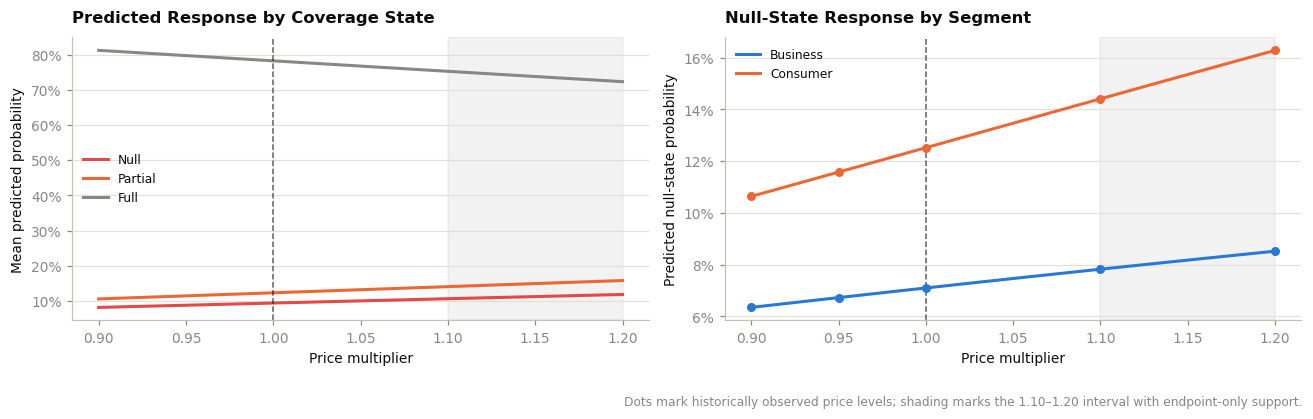

Segment,P(null) at 0.90,P(null) at 1.20,Range Swing
Business,6.3%,8.5%,+2.2%
Consumer,10.6%,16.3%,+5.6%


Segment,0.90,0.95,1.00,1.10,1.20
Consumer,11.0%,12.0%,12.7%,17.3%,22.3%
Business,7.4%,7.0%,7.2%,8.6%,9.4%


In [13]:
# Evaluate Raw Price Response
GRID = np.round(np.linspace(0.90, 1.20, 25), 4)
OBS_PRICES = [0.90, 0.95, 1.00, 1.10, 1.20]
SWEEP_SIGN = {'null': 1, 'partial': 1, 'full': -1}

sweep = pd.DataFrame([
    {
        **dict(
            zip(
                CLASSES,
                raw_score(
                    X[te],
                    trips[te],
                    multiplier,
                ).mean(axis=0),
            )
        ),
        'price_multiplier': multiplier,
    }
    for multiplier in GRID
]).set_index('price_multiplier')

sweep_display = (
    sweep.iloc[::4]
    .rename_axis('Price Multiplier')
    .reset_index()
    .rename(columns={
        'null': 'Null',
        'partial': 'Partial',
        'full': 'Full',
    })
)

display(
    sweep_display.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Null': '{:.1%}',
        'Partial': '{:.1%}',
        'Full': '{:.1%}',
    })
    .set_caption('Modeled Coverage-State Response by Price')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col0, td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

violations = {
    coverage_class: int(
        (
            sweep[coverage_class].diff().dropna()
            * SWEEP_SIGN[coverage_class]
            < -1e-9
        ).sum()
    )
    for coverage_class in CLASSES
}

flat_steps = {
    coverage_class: int(
        (
            sweep[coverage_class]
            .diff()
            .abs()
            .dropna()
            < 1e-9
        ).sum()
    )
    for coverage_class in CLASSES
}

expected_coverage = (
    sweep['full']
    + 0.5 * sweep['partial']
)

coverage_violations = int(
    (expected_coverage.diff().dropna() > 1e-9).sum()
)

maximum_sum_error = (
    sweep.sum(axis=1)
    .sub(1.0)
    .abs()
    .max()
)

assert all(
    value == 0
    for value in violations.values()
), f'monotonicity violation found: {violations}'

assert coverage_violations == 0, (
    'expected coverage increased somewhere in the sweep'
)

assert np.allclose(
    sweep.sum(axis=1),
    1.0,
    atol=1e-6,
), 'sweep probabilities do not sum to one'

sweep_audit = pd.DataFrame({
    'Validation': [
        'Null-state monotonicity',
        'Partial-state monotonicity',
        'Full-state monotonicity',
        'Expected-coverage monotonicity',
        'Probability sum',
        'Flat-step check',
    ],
    'Status': [
        'Pass' if violations['null'] == 0 else 'Review',
        'Pass' if violations['partial'] == 0 else 'Review',
        'Pass' if violations['full'] == 0 else 'Review',
        'Pass' if coverage_violations == 0 else 'Review',
        'Pass' if maximum_sum_error <= 1e-6 else 'Review',
        'Pass' if sum(flat_steps.values()) == 0 else 'Review',
    ],
    'Result': [
        f"{violations['null']} decreases",
        f"{violations['partial']} decreases",
        f"{violations['full']} increases",
        f'{coverage_violations} increases',
        f'Maximum error: {maximum_sum_error:.2e}',
        f'{sum(flat_steps.values())} flat steps',
    ],
})


def audit_status_style(value):
    if value == 'Pass':
        return 'color: #237a3b; font-weight: bold'
    return 'color: #b23c17; font-weight: bold'


display(
    sweep_audit.style
    .hide(axis='index')
    .set_caption('Raw Price-Response Validation')
    .map(
        audit_status_style,
        subset=['Status'],
    )
    .set_table_styles(TABLE_STYLES)
)

i_null = IDX['null']
test_business = trips.loc[
    te, 'is_business'
].to_numpy(dtype=int)

segment_curves = {}

for segment_value, segment_name in [
    (1, 'Business'),
    (0, 'Consumer'),
]:
    mask = test_business == segment_value

    segment_curves[segment_name] = np.array([
        raw_score(
            X[te][mask],
            trips[te][mask],
            multiplier,
        )[:, i_null].mean()
        for multiplier in GRID
    ])

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 3.8),
)

state_colors = {
    'null': RED,
    'partial': ACCENT2,
    'full': MUTED,
}

for coverage_class in CLASSES:
    axes[0].plot(
        sweep.index,
        sweep[coverage_class],
        color=state_colors[coverage_class],
        linewidth=2,
        label=coverage_class.title(),
    )

axes[0].axvline(
    1.0,
    color=INK,
    linestyle='--',
    linewidth=1,
    alpha=0.65,
)

axes[0].axvspan(
    1.10,
    1.20,
    color=INK,
    alpha=0.05,
)

axes[0].set(
    xlabel='Price multiplier',
    ylabel='Mean predicted probability',
)

axes[0].set_title(
    'Predicted Response by Coverage State',
    loc='left',
    fontweight='bold',
    pad=10,
)

axes[0].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[0].grid(
    axis='y',
    color=GRIDLINE,
    linewidth=0.8,
)

axes[0].legend(
    frameon=False,
    fontsize=8,
)

segment_colors = {
    'Business': ACCENT,
    'Consumer': ACCENT2,
}

for segment_name, curve in segment_curves.items():
    axes[1].plot(
        GRID,
        curve,
        color=segment_colors[segment_name],
        linewidth=2,
        label=segment_name,
    )

    observed_curve = np.interp(
        OBS_PRICES,
        GRID,
        curve,
    )

    axes[1].scatter(
        OBS_PRICES,
        observed_curve,
        color=segment_colors[segment_name],
        s=24,
        zorder=3,
    )

axes[1].axvline(
    1.0,
    color=INK,
    linestyle='--',
    linewidth=1,
    alpha=0.65,
)

axes[1].axvspan(
    1.10,
    1.20,
    color=INK,
    alpha=0.05,
)

axes[1].set(
    xlabel='Price multiplier',
    ylabel='Predicted null-state probability',
)

axes[1].set_title(
    'Null-State Response by Segment',
    loc='left',
    fontweight='bold',
    pad=10,
)

axes[1].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[1].grid(
    axis='y',
    color=GRIDLINE,
    linewidth=0.8,
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

fig.text(
    0.99,
    0.02,
    'Dots mark historically observed price levels; shading marks the '
    '1.10–1.20 interval with endpoint-only support.',
    ha='right',
    color=MUTED,
    fontsize=8,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

segment_summary = pd.DataFrame([
    {
        'Segment': segment_name,
        'P(null) at 0.90': curve[0],
        'P(null) at 1.20': curve[-1],
        'Range Swing': curve[-1] - curve[0],
    }
    for segment_name, curve in segment_curves.items()
])

display(
    segment_summary.style
    .hide(axis='index')
    .format({
        'P(null) at 0.90': '{:.1%}',
        'P(null) at 1.20': '{:.1%}',
        'Range Swing': '{:+.1%}',
    })
    .set_caption('Modeled Null-State Response Across the Price Range')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

observed_null = (
    trips.assign(
        null_state=trips['y'].eq('null').astype(float)
    )
    .pivot_table(
        index='is_business',
        columns='price_multiplier',
        values='null_state',
    )
    .reindex(columns=OBS_PRICES)
    .rename(index={
        0: 'Consumer',
        1: 'Business',
        False: 'Consumer',
        True: 'Business',
    })
    .rename_axis('Segment')
    .reset_index()
)

observed_null.columns = [
    'Segment',
    *[f'{price:.2f}' for price in OBS_PRICES],
]

observed_price_columns = [
    f'{price:.2f}'
    for price in OBS_PRICES
]

display(
    observed_null.style
    .hide(axis='index')
    .format({
        column: '{:.1%}'
        for column in observed_price_columns
    })
    .set_caption('Observed Null-State Rate by Segment and Price')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3, td.col4, td.col5',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


<hr>
<div>
<h3>6.2 · Regional Price-Response Holdout</h3>
<p><strong>Purpose:</strong> Tests whether the price response estimated from other regions transfers to Asia-Pacific. This complements the temporal holdout by evaluating geographic generalization of the price effect.</p>
<p><strong>Design Notes:</strong> The holdout is structured to preserve the Asia-Pacific baseline while withholding its market-test price response. This allows differences in the holdout to be interpreted as price-response error rather than a failure to estimate the region’s baseline behavior.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Holdout Construction.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Fit Stage 1 using standard-price trips from all regions, including Asia-Pacific.</li>
<li>Fit Stage 2 using price variation from regions other than Asia-Pacific.</li>
<li>Exclude Asia-Pacific elevated-price outcomes from calibration, model selection, and Stage 2 coefficient estimation.</li>
<li>Evaluate the completed model on Asia-Pacific trips from the market-test period.</li>
<li>Use only price levels that have sufficient observed support in both the Stage 2 estimation sample and the Asia-Pacific holdout.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Comparison with the Temporal Holdout.</strong> The temporal test evaluates whether overall predictive performance and calibration remain stable on later trips. The regional holdout evaluates whether a price response learned outside Asia-Pacific transfers to that region. These are complementary validation tests.</li>
<li style="margin-bottom: 0.7em;"><strong>Response Comparison.</strong> The holdout compares observed and predicted changes from the standard price rather than relying only on absolute outcome rates.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The observed response is the change in the Asia-Pacific outcome rate from the standard price to an elevated price.</li>
<li>The predicted response is the corresponding change produced by the fitted model for the same holdout population.</li>
<li>Customer and trip characteristics remain fixed while price changes.</li>
<li>The response ratio is calculated as:</li>
</ul>
    
$$
\text{response ratio}
=
\frac{\text{observed change from the standard price}}
 {\text{predicted change from the standard price}}
$$
<p>A ratio above 1 indicates that the observed customer response is stronger than the model predicts.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Uncertainty.</strong> Observed and predicted rates, response slopes, and their ratio should be reported with sample sizes and uncertainty intervals. The ratio should be interpreted cautiously when the predicted change is small.</li>
<li style="margin-bottom: 0.7em;"><strong>Simulation Sensitivity.</strong> The regional holdout is used to create two simulation scenarios:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><strong>Base Response.</strong> Uses the fitted Stage 2 price coefficients without adjustment.</li>
<li><strong>Stronger-Response Sensitivity.</strong> Increases the Stage 2 price response using the holdout ratio.</li>
</ul>
<p>The sensitivity factor is applied to the Stage 2 log-price terms, not directly to the final probabilities:</p>
    
$$
\eta_c^{(s)}
=
\log P_c^{(1)}
+
s\left(
\beta_c\ell
+
\gamma_c\ell I_{\text{business}}
\right)
$$
<p>Here, \(s=1.00\) represents the base model and \(s=1.74\) represents the current stronger-response sensitivity. The probabilities are then recalculated and normalized across all three coverage states.</p>
<p style="margin-bottom: 0;">This method:</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Leaves the standard-price baseline unchanged</li>
<li>Preserves probabilities between zero and one</li>
<li>Preserves the requirement that probabilities sum to one</li>
<li>Allows the adjusted response curves to be retested for smoothness and economic coherence</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation.</strong> The 1.00 and 1.74 cases are sensitivity scenarios, not statistical lower and upper bounds. The 1.74 factor is derived from the Asia-Pacific <code>null</code> response and should not be assumed to apply equally to every state, region, segment, or candidate price without further evidence.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>At a price multiplier of 1.20, the current model predicts an Asia-Pacific <code>null</code> rate of about 9.9%, compared with an observed rate of about 13.3%. The model underpredicts the observed <code>null</code> rate by about 3.4 percentage points.</li>
<li>Across the held-out price levels, the current observed-to-predicted response ratio is 1.74. This indicates that the observed Asia-Pacific response is stronger than the fitted model predicts.</li>
<li>If the same underprediction occurs elsewhere, the base simulation could overstate revenue at higher prices by understating movement toward <code>null</code> coverage.</li>
<li>The 12-month simulation therefore reports both the unadjusted model response and a stronger-response sensitivity using the current 1.74 factor.</li>
<li>The sensitivity result should be presented as a cautious scenario rather than a guaranteed bound on the revenue outcome.</li>
</ol>
</div>


In [14]:
# Regional Holdout
i_null = IDX['null']

is_asia_pacific = trips['region'].isin([
    'asia',
    'oceania',
]).to_numpy()

h_tr = tr & ~is_asia_pacific
h_s1 = h_tr & trips['price_multiplier'].eq(1.0).to_numpy()
h_te = (
    is_asia_pacific
    & trips['month'].between(8, 15).to_numpy()
)

g_h = HistGradientBoostingClassifier(
    max_iter=400,
    learning_rate=0.06,
    max_leaf_nodes=31,
    min_samples_leaf=40,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=0,
).fit(X[h_s1], y[h_s1])

ord_h = [
    list(g_h.classes_).index(c)
    for c in CLASSES
]


def s1_h(Xf):
    P = g_h.predict_proba(Xf)[:, ord_h]
    P = np.clip(P, 1e-6, None)
    return P / P.sum(axis=1, keepdims=True)


res_h = minimize(
    nll,
    np.zeros(len(FIT_CLASSES) * len(TERMS)),
    args=(
        np.log(s1_h(X[h_tr])),
        price_design(trips[h_tr]),
        yi[h_tr],
    ),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 500},
)

if not res_h.success:
    raise RuntimeError(
        f'regional-holdout fit did not converge: {res_h.message}'
    )

B_h = res_h.x.reshape(
    len(FIT_CLASSES),
    len(TERMS),
)

eta_h = np.log(s1_h(X[h_te]))
Z_h = price_design(trips[h_te])

for k, coverage_class in enumerate(FIT_CLASSES):
    eta_h[:, IDX[coverage_class]] += Z_h @ B_h[k]

P_h = softmax(eta_h)

holdout_results = (
    pd.DataFrame({
        'Price Multiplier': trips.loc[
            h_te, 'price_multiplier'
        ].to_numpy(),
        'Predicted Null Rate': P_h[:, i_null],
        'Observed Null Rate': (
            y[h_te] == 'null'
        ).astype(float),
    })
    .groupby('Price Multiplier', as_index=False)
    .agg(
        Trips=('Observed Null Rate', 'size'),
        Predicted_Null_Rate=(
            'Predicted Null Rate',
            'mean',
        ),
        Observed_Null_Rate=(
            'Observed Null Rate',
            'mean',
        ),
    )
    .rename(columns={
        'Predicted_Null_Rate': 'Predicted Null Rate',
        'Observed_Null_Rate': 'Observed Null Rate',
    })
)

holdout_results['Prediction Gap'] = (
    holdout_results['Predicted Null Rate']
    - holdout_results['Observed Null Rate']
)

display(
    holdout_results.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Trips': '{:,.0f}',
        'Predicted Null Rate': '{:.1%}',
        'Observed Null Rate': '{:.1%}',
        'Prediction Gap': '{:+.1%}',
    })
    .set_caption('Asia-Pacific Regional Holdout: Null-State Response')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': (
                    'td.col0, td.col1, td.col2, td.col3, td.col4'
                ),
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

if len(holdout_results) >= 2:
    predicted_slope = (
        holdout_results['Predicted Null Rate'].iloc[-1]
        - holdout_results['Predicted Null Rate'].iloc[0]
    )

    observed_slope = (
        holdout_results['Observed Null Rate'].iloc[-1]
        - holdout_results['Observed Null Rate'].iloc[0]
    )

    RESPONSE_RATIO = (
        float(observed_slope / predicted_slope)
        if abs(predicted_slope) > 1e-9
        else np.nan
    )
else:
    predicted_slope = np.nan
    observed_slope = np.nan
    RESPONSE_RATIO = np.nan

if not np.isfinite(RESPONSE_RATIO):
    assessment = (
        'Insufficient price variation to estimate '
        'a response ratio'
    )
elif RESPONSE_RATIO > 1.25:
    assessment = (
        'Observed response is stronger; retain the fitted '
        'and stronger-response sensitivity scenarios'
    )
elif RESPONSE_RATIO < 0.80:
    assessment = (
        'Observed response is weaker; retain both response '
        'scenarios for sensitivity testing'
    )
else:
    assessment = (
        'Observed and predicted responses are broadly aligned'
    )

response_summary = pd.DataFrame({
    'Predicted Change': [predicted_slope],
    'Observed Change': [observed_slope],
    'Observed / Predicted': [RESPONSE_RATIO],
    'Assessment': [assessment],
})

display(
    response_summary.style
    .hide(axis='index')
    .format({
        'Predicted Change': '{:+.1%}',
        'Observed Change': '{:+.1%}',
        'Observed / Predicted': (
            lambda value: (
                f'{value:.2f}×'
                if np.isfinite(value)
                else 'Not available'
            )
        ),
    })
    .set_caption('Response Across the Held-Out Price Levels')
    .set_properties(
        subset=['Observed / Predicted'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col0, td.col1, td.col2',
                'props': [('text-align', 'right !important')],
            },
            {
                'selector': 'td.col3',
                'props': [('text-align', 'left !important')],
            },
        ]
    )
)


Price Multiplier,Trips,Predicted Null Rate,Observed Null Rate,Prediction Gap
1.10,"2,687",9.0%,11.8%,-2.8%
1.20,"2,759",9.9%,13.3%,-3.4%


Predicted Change,Observed Change,Observed / Predicted,Assessment
+0.9%,+1.5%,1.76×,Observed response is stronger; retain the fitted and stronger-response sensitivity scenarios


<hr>
<div>
<h2>7 · Stage 1 Probability Calibration</h2>
<p><strong>Purpose:</strong> Adjusts the raw Stage 1 probabilities so they align more closely with observed coverage rates at the standard price. The calibrated probabilities become the fixed baseline used by Stage 2.</p>
<p><strong>Design Notes:</strong> Calibration is performed after Stage 1 is fitted and before the Stage 2 price response is estimated. A separate calibration period allows the adjustment to be estimated independently while preserving the test period for the final evaluation.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Calibration Population.</strong> The calibrator uses standard-price trips from months 16 through 19.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Standard-price trips are required because Stage 1 represents behavior at the standard price.</li>
<li>Including off-standard trips could allow price response to enter the baseline calibration.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Calibration Method.</strong> A separate isotonic regression is fitted for each coverage state.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Isotonic regression learns a monotonic mapping between the raw predicted probability and the observed outcome rate.</li>
<li>The method can correct probability levels without reversing the model’s ranking.</li>
<li>After the three class probabilities are calibrated separately, they are normalized to remain between zero and one and sum to one.</li>
<li>Calibration performance is evaluated after normalization.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Calibration Selection.</strong> The standard-price calibration sample is divided chronologically into two portions.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The earlier 70% is used to fit a decision-stage calibrator.</li>
<li>The later 30% is used to compare the raw and calibrated probabilities.</li>
<li>The test period is not used to select the calibration method.</li>
</ul>
<p>Calibration is selected when it lowers multiclass Brier score without materially worsening log loss or the Brier score for any coverage state. Brier score measures the squared difference between predicted probabilities and observed outcomes, so lower values indicate more accurate probabilities.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Final Calibrator.</strong> After isotonic calibration is selected, the calibrator is refitted using the full standard-price calibration sample from months 16 through 19.</li>
<li style="margin-bottom: 0.7em;"><strong>Connection to Stage 2.</strong> The calibrated Stage 1 probabilities enter Stage 2 as fixed offsets.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Stage 2 estimates how those baseline probabilities change with price.</li>
<li>At the standard price, the Stage 2 price terms equal zero and the calibrated Stage 1 probabilities remain unchanged.</li>
<li>The complete two-stage model is evaluated separately across all observed prices in the untouched test period.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Final Evaluation.</strong> Calibration is assessed using:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Multiclass Brier score</li>
<li>Class-level Brier scores</li>
<li>Multiclass log loss</li>
<li>Calibration in the large</li>
<li>Calibration curves for <code>null</code>, <code>partial</code>, and <code>full</code></li>
<li>Performance by observed price level after Stage 2 is added</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Isotonic calibration improves the Brier score for all three coverage states on the held-out 30% decision sample, so it is selected for the final study model.</li>
<li>Before calibration, the average predicted <code>full</code> probability is 0.7814, compared with an observed <code>full</code> rate of 0.7790. The raw probabilities are therefore already close in aggregate.</li>
<li>This aggregate agreement demonstrates calibration in the large but does not establish calibration across different predicted probability ranges.</li>
<li>Improvements on the untouched test period are small but consistent with the decision-sample results, supporting the calibration choice.</li>
<li>Final reporting should include the raw and calibrated Brier scores, log loss, and calibration curves so the size and consistency of the improvement are visible.</li>
</ol>
</div>


Metric,Raw,Isotonic,Change
Null Brier score,0.08809,0.08808,-0.00001
Partial Brier score,0.09225,0.09176,-0.00049
Full Brier score,0.15956,0.15935,-0.00020
Log loss,0.63846,0.63610,-0.00236


Selection Criterion,Selected Method,Evaluation Records,Test Period Used
Lower held-out log loss,Isotonic,"6,619",No


Metric,Raw,Isotonic,Change
Null Brier score,0.08986,0.08984,-0.00002
Partial Brier score,0.10614,0.10603,-0.00011
Full Brier score,0.17159,0.17160,+0.00001
Log loss,0.67809,0.67821,+0.00013


Coverage Level,Observed,Raw,Isotonic,Raw Gap,Isotonic Gap
Null,10.1%,9.5%,10.1%,-0.6%,+0.0%
Partial,12.0%,12.4%,10.6%,+0.4%,-1.4%
Full,77.9%,78.1%,79.3%,+0.2%,+1.4%


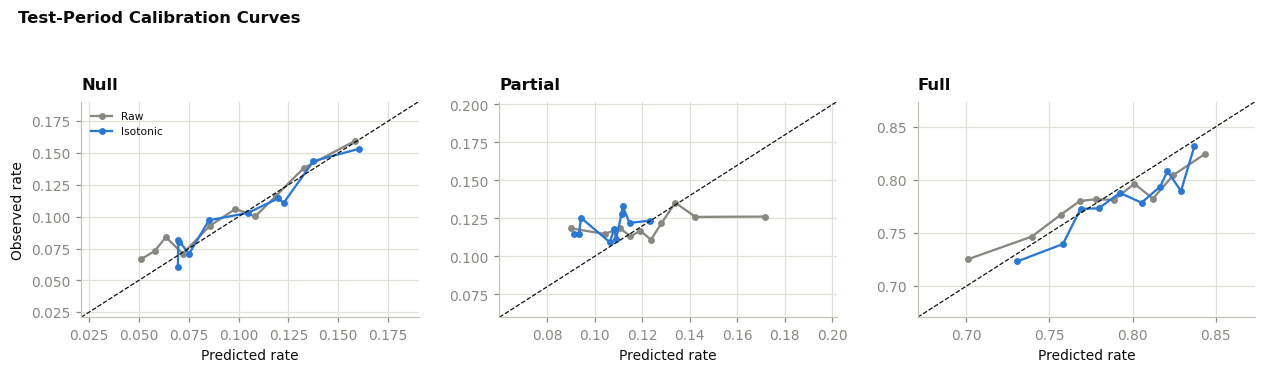

In [15]:
# Calibrate Probabilities
def brier_by_class(P, yv):
    return pd.Series({
        coverage_class: brier_score_loss(
            (yv == coverage_class).astype(int),
            P[:, i],
        )
        for i, coverage_class in enumerate(CLASSES)
    })


def _calibrate_with(calibrators, P):
    Q = np.column_stack([
        calibrators[coverage_class].predict(P[:, i])
        for i, coverage_class in enumerate(CLASSES)
    ])

    Q = np.clip(Q, 1e-6, 1 - 1e-6)
    return Q / Q.sum(axis=1, keepdims=True)


calib_rng = np.random.default_rng(0)
ca_positions = np.where(ca)[0]
permutation = calib_rng.permutation(len(ca_positions))
n_fit = int(0.70 * len(ca_positions))

ca_fit = np.zeros_like(ca)
ca_eval = np.zeros_like(ca)

ca_fit[ca_positions[permutation[:n_fit]]] = True
ca_eval[ca_positions[permutation[n_fit:]]] = True

P_ca_fit = raw_score(
    X[ca_fit],
    trips[ca_fit],
)

CALS_decision = {
    coverage_class: IsotonicRegression(
        out_of_bounds='clip'
    ).fit(
        P_ca_fit[:, i],
        (y[ca_fit] == coverage_class).astype(int),
    )
    for i, coverage_class in enumerate(CLASSES)
}

P_ca_eval_raw = raw_score(
    X[ca_eval],
    trips[ca_eval],
)

P_ca_eval_iso = _calibrate_with(
    CALS_decision,
    P_ca_eval_raw,
)

decision_brier_raw = brier_by_class(
    P_ca_eval_raw,
    y[ca_eval],
)

decision_brier_iso = brier_by_class(
    P_ca_eval_iso,
    y[ca_eval],
)

decision_ll_raw = LL(
    y[ca_eval],
    P_ca_eval_raw,
)

decision_ll_iso = LL(
    y[ca_eval],
    P_ca_eval_iso,
)

USE_CAL = bool(decision_ll_iso < decision_ll_raw)
selected_method = 'Isotonic' if USE_CAL else 'Raw'

decision_metrics = pd.DataFrame({
    'Metric': [
        'Null Brier score',
        'Partial Brier score',
        'Full Brier score',
        'Log loss',
    ],
    'Raw': [
        decision_brier_raw['null'],
        decision_brier_raw['partial'],
        decision_brier_raw['full'],
        decision_ll_raw,
    ],
    'Isotonic': [
        decision_brier_iso['null'],
        decision_brier_iso['partial'],
        decision_brier_iso['full'],
        decision_ll_iso,
    ],
})

decision_metrics['Change'] = (
    decision_metrics['Isotonic']
    - decision_metrics['Raw']
)

display(
    decision_metrics.style
    .hide(axis='index')
    .format({
        'Raw': '{:.5f}',
        'Isotonic': '{:.5f}',
        'Change': '{:+.5f}',
    })
    .set_caption(
        'Calibration Decision: Held-Out 30% of the Calibration Window'
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

selection_summary = pd.DataFrame({
    'Selection Criterion': ['Lower held-out log loss'],
    'Selected Method': [selected_method],
    'Evaluation Records': [ca_eval.sum()],
    'Test Period Used': ['No'],
})

display(
    selection_summary.style
    .hide(axis='index')
    .format({'Evaluation Records': '{:,.0f}'})
    .set_caption('Calibration Selection Summary')
    .set_properties(
        subset=['Selected Method'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col2',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

P_ca = raw_score(
    X[ca],
    trips[ca],
)

CALS = {
    coverage_class: IsotonicRegression(
        out_of_bounds='clip'
    ).fit(
        P_ca[:, i],
        (y[ca] == coverage_class).astype(int),
    )
    for i, coverage_class in enumerate(CLASSES)
}


def calibrate(P):
    if USE_CAL:
        return _calibrate_with(CALS, P)

    return P.copy()


P_te_iso = _calibrate_with(CALS, P_te)
P_te_cal = calibrate(P_te)

test_brier_raw = brier_by_class(
    P_te,
    y[te],
)

test_brier_iso = brier_by_class(
    P_te_iso,
    y[te],
)

test_metrics = pd.DataFrame({
    'Metric': [
        'Null Brier score',
        'Partial Brier score',
        'Full Brier score',
        'Log loss',
    ],
    'Raw': [
        test_brier_raw['null'],
        test_brier_raw['partial'],
        test_brier_raw['full'],
        LL(y[te], P_te),
    ],
    'Isotonic': [
        test_brier_iso['null'],
        test_brier_iso['partial'],
        test_brier_iso['full'],
        LL(y[te], P_te_iso),
    ],
})

test_metrics['Change'] = (
    test_metrics['Isotonic']
    - test_metrics['Raw']
)

display(
    test_metrics.style
    .hide(axis='index')
    .format({
        'Raw': '{:.5f}',
        'Isotonic': '{:.5f}',
        'Change': '{:+.5f}',
    })
    .set_caption('Test-Period Calibration Results — Reporting Only')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

aggregate_calibration = pd.DataFrame({
    'Coverage Level': [
        coverage_class.title()
        for coverage_class in CLASSES
    ],
    'Observed': [
        (y[te] == coverage_class).mean()
        for coverage_class in CLASSES
    ],
    'Raw': P_te.mean(axis=0),
    'Isotonic': P_te_iso.mean(axis=0),
})

aggregate_calibration['Raw Gap'] = (
    aggregate_calibration['Raw']
    - aggregate_calibration['Observed']
)

aggregate_calibration['Isotonic Gap'] = (
    aggregate_calibration['Isotonic']
    - aggregate_calibration['Observed']
)

display(
    aggregate_calibration.style
    .hide(axis='index')
    .format({
        'Observed': '{:.1%}',
        'Raw': '{:.1%}',
        'Isotonic': '{:.1%}',
        'Raw Gap': '{:+.1%}',
        'Isotonic Gap': '{:+.1%}',
    })
    .set_caption('Aggregate Test-Period Calibration')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': (
                    'td.col1, td.col2, td.col3, td.col4, td.col5'
                ),
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(11.5, 3.4),
)

for i, (coverage_class, ax) in enumerate(
    zip(CLASSES, axes)
):
    plotted_points = []

    for probabilities, label, color in [
        (P_te, 'Raw', MUTED),
        (P_te_iso, 'Isotonic', ACCENT),
    ]:
        try:
            observed_rate, predicted_rate = calibration_curve(
                (y[te] == coverage_class).astype(int),
                probabilities[:, i],
                n_bins=10,
                strategy='quantile',
            )
        except ValueError:
            continue

        plotted_points.extend(
            np.concatenate([
                observed_rate,
                predicted_rate,
            ])
        )

        ax.plot(
            predicted_rate,
            observed_rate,
            marker='o',
            markersize=3.5,
            color=color,
            linewidth=1.5,
            label=label,
        )

    if plotted_points:
        lower = max(
            0,
            min(plotted_points) - 0.03,
        )
        upper = min(
            1,
            max(plotted_points) + 0.03,
        )

        if upper - lower < 0.10:
            midpoint = (lower + upper) / 2
            lower = max(0, midpoint - 0.05)
            upper = min(1, midpoint + 0.05)
    else:
        lower, upper = 0, 1

    ax.plot(
        [lower, upper],
        [lower, upper],
        color=INK,
        linestyle='--',
        linewidth=0.8,
    )

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)

    ax.set_title(
        coverage_class.title(),
        loc='left',
        fontweight='bold',
        pad=8,
    )

    ax.set_xlabel('Predicted rate')

    if i == 0:
        ax.set_ylabel('Observed rate')
        ax.legend(
            frameon=False,
            fontsize=7,
        )

    ax.grid(
        color=GRIDLINE,
        linewidth=0.8,
    )

fig.suptitle(
    'Test-Period Calibration Curves',
    x=0.01,
    ha='left',
    fontweight='bold',
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


<hr>
<div>
<h2>8 · Final Scenario Scorer</h2>
<p><strong>Purpose:</strong> Combines the fitted Stage 1 model, selected probability calibrator, Stage 2 price response, and regional response sensitivity into one scoring interface for the 12-month simulation.</p>
<p><strong>Design Notes:</strong> The calibration method was selected in Section 6 before the test period was evaluated. This section does not choose between raw and calibrated probabilities; it defines how the selected model components are applied consistently to every scenario.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Scoring Interface.</strong> The simulation calls a single function:
<p>``<code>python score_trips( features, price_multiplier, response_scale = 1.0 ) </code>``</p><br>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>features</code> contains the approved 15 pre-outcome model features.</li>
<li><code>price_multiplier</code> specifies the candidate price relative to the standard price and may be supplied as a single value or a row-aligned series.</li>
<li><code>response_scale</code> controls the strength of the Stage 2 price response.</li>
<li>A value of <code>1.0</code> uses the fitted base response.</li>
<li>A value of <code>1.74</code> applies the current stronger-response sensitivity from the regional holdout in Section 6.2.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Input Contract.</strong> The scorer accepts only information available at the model’s defined prediction point.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The input schema, data types, and row identifiers are validated before scoring.</li>
<li><code>days_traveled</code> and <code>lines_traveling</code> are not model inputs.</li>
<li>Label-defining fields, downstream outcomes, synthetic latent variables, price fields embedded in the feature matrix, and <code>substitute_ease</code> are rejected.</li>
<li>Feature construction occurs inside the scoring pipeline so the same transformations are used during model fitting and simulation.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Scoring Sequence.</strong> For every candidate-price scenario, the scorer:
<ol style="margin: 0.15em 0 0; padding-left: 1.5em;">
<li>Validates the incoming feature schema.</li>
<li>Generates the raw Stage 1 baseline probabilities.</li>
<li>Applies the selected Stage 1 isotonic calibrator.</li>
<li>Uses the calibrated probabilities as fixed offsets in Stage 2.</li>
<li>Applies the requested price multiplier.</li>
<li>Applies <code>response_scale</code> to the Stage 2 log-price terms.</li>
<li>Converts the adjusted values into normalized probabilities for <code>null</code>, <code>partial</code>, and <code>full</code>.</li>
<li>Returns the probabilities with the original row identifiers.</li>
</ol></li>
<li style="margin-bottom: 0.7em;"><strong>Response Sensitivity.</strong> <code>response_scale</code> adjusts the Stage 2 price terms rather than multiplying the final probabilities.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>At the standard price, the log-price term equals zero, so changing <code>response_scale</code> does not change the calibrated Stage 1 baseline.</li>
<li>The stronger-response case is a sensitivity scenario, not a statistical upper or lower bound.</li>
<li>All adjusted probability curves are rechecked for smoothness and economic coherence before use in the simulation.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Output Contract.</strong> The scorer returns one row for every input trip with:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>P(null)</code></li>
<li><code>P(partial)</code></li>
<li><code>P(full)</code></li>
<li>The original row identifier</li>
<li>The applied <code>price_multiplier</code></li>
<li>The applied <code>response_scale</code></li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Automated Validation.</strong> Every scoring run verifies that:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>No required feature is missing.</li>
<li>No prohibited feature enters the model.</li>
<li>Input and output rows remain aligned.</li>
<li>All probabilities are finite and between zero and one.</li>
<li>The three probabilities sum to one for every row.</li>
<li>Standard-price probabilities are unaffected by <code>response_scale</code>.</li>
<li>Expected coverage does not increase as price rises.</li>
<li>Results are reproducible for identical inputs and parameters.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The isotonic calibrator was selected using the held-out decision portion of the calibration period, where it improved the Brier score for all three coverage states.</li>
<li style="margin-bottom: 0.7em;">On the untouched test period, raw and calibrated performance is effectively tied:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Log loss is 0.6781 for raw probabilities and 0.6782 for isotonic probabilities.</li>
<li>Mean Brier score is 0.1225 for both at the displayed precision.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The currently reported aggregate mean-rate error is 1.2% for raw probabilities and 2.8% for isotonic probabilities. This comparison measures calibration in the large only and does not describe calibration across different probability ranges.</li>
<li style="margin-bottom: 0.7em;">The test results do not demonstrate an out-of-time advantage for isotonic calibration. The calibrator remains in the final study model because it was selected using the previously defined calibration decision rule without consulting the test period.</li>
<li style="margin-bottom: 0.7em;">Smoothness and economic coherence are evaluated using the full candidate-price sweep in Section 6.1 rather than scoring only three selected prices.</li>
<li style="margin-bottom: 0.7em;">The scorer provides the single probability interface used by the 12-month simulation for both the base and stronger-response sensitivity scenarios.</li>
</ol>
</div>


In [16]:
# Choose Production Scorer
candidates = {
    'Raw': P_te,
    'Isotonic': P_te_iso,
}

observed_test_share = np.array([
    (y[te] == coverage_class).mean()
    for coverage_class in CLASSES
])

test_scores = pd.DataFrame([
    {
        'Method': method,
        'Log Loss': LL(y[te], probabilities),
        'Mean Brier': brier_by_class(
            probabilities,
            y[te],
        ).mean(),
        'Aggregate Probability Error': np.abs(
            probabilities.mean(axis=0)
            - observed_test_share
        ).sum(),
        'Mean AUC': np.mean([
            roc_auc_score(
                (y[te] == coverage_class).astype(int),
                probabilities[:, i],
            )
            for i, coverage_class in enumerate(CLASSES)
        ]),
    }
    for method, probabilities in candidates.items()
])

display(
    test_scores.style
    .hide(axis='index')
    .format({
        'Log Loss': '{:.5f}',
        'Mean Brier': '{:.5f}',
        'Aggregate Probability Error': '{:.5f}',
        'Mean AUC': '{:.5f}',
    })
    .set_caption(
        'Test-Period Production-Scorer Comparison — Reporting Only'
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3, td.col4',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

CAL_TOL = 0.02

mean_brier_improves = bool(
    decision_brier_iso.mean()
    < decision_brier_raw.mean()
)

no_class_brier_worse = bool(
    (
        decision_brier_iso
        <= decision_brier_raw * (1 + CAL_TOL)
    ).all()
)

log_loss_not_worse = bool(
    decision_ll_iso
    <= decision_ll_raw * (1 + CAL_TOL)
)

USE_CAL = bool(
    mean_brier_improves
    and no_class_brier_worse
    and log_loss_not_worse
)

selection_checks = pd.DataFrame({
    'Criterion': [
        'Mean Brier score improves',
        'No class Brier score exceeds tolerance',
        'Log loss remains within tolerance',
    ],
    'Threshold': [
        'Isotonic < Raw',
        f'≤ {CAL_TOL:.0%} deterioration',
        f'≤ {CAL_TOL:.0%} deterioration',
    ],
    'Status': [
        'Pass' if mean_brier_improves else 'Review',
        'Pass' if no_class_brier_worse else 'Review',
        'Pass' if log_loss_not_worse else 'Review',
    ],
})


def selection_status_style(value):
    if value == 'Pass':
        return 'color: #237a3b; font-weight: bold'
    return f'color: {RED}; font-weight: bold'


display(
    selection_checks.style
    .hide(axis='index')
    .set_caption(
        f'Calibration Selection: {"Isotonic" if USE_CAL else "Raw"}'
    )
    .map(
        selection_status_style,
        subset=['Status'],
    )
    .set_table_styles(TABLE_STYLES)
)


def score_trips(
    Xf,
    df,
    mult=None,
    response_scale=1.0,
):
    """Score trips under a price and response-sensitivity scenario."""
    assert list(Xf.columns) == EXPECTED_COLS, (
        'unexpected feature columns passed to score_trips'
    )

    assert len(Xf) == len(df), (
        'features and trip frame row counts do not match'
    )

    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)

    for k, coverage_class in enumerate(FIT_CLASSES):
        eta[:, IDX[coverage_class]] += (
            response_scale * (Z @ B[k])
        )

    P = softmax(eta)

    if USE_CAL:
        P = _calibrate_with(CALS, P)

    assert np.isfinite(P).all(), (
        'non-finite probabilities from score_trips'
    )

    assert (
        (P >= 0).all()
        and (P <= 1).all()
    ), 'probabilities outside the [0, 1] range'

    assert np.allclose(
        P.sum(axis=1),
        1.0,
        atol=1e-6,
    ), 'probabilities do not sum to one'

    return P


sanity_results = []

for multiplier in [0.90, 1.00, 1.20]:
    mean_probability = score_trips(
        X[te],
        trips[te],
        multiplier,
    ).mean(axis=0)

    sanity_results.append({
        'Price Multiplier': multiplier,
        **{
            coverage_class.title(): probability
            for coverage_class, probability
            in zip(CLASSES, mean_probability)
        },
    })

sanity_results = pd.DataFrame(sanity_results)

display(
    sanity_results.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Null': '{:.1%}',
        'Partial': '{:.1%}',
        'Full': '{:.1%}',
    })
    .set_caption('Production-Scorer Sanity Check')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col0, td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


Method,Log Loss,Mean Brier,Aggregate Probability Error,Mean AUC
Raw,0.67809,0.12253,0.01211,0.54714
Isotonic,0.67821,0.12249,0.02820,0.54724


Criterion,Threshold,Status
Mean Brier score improves,Isotonic < Raw,Pass
No class Brier score exceeds tolerance,≤ 2% deterioration,Pass
Log loss remains within tolerance,≤ 2% deterioration,Pass


Price Multiplier,Null,Partial,Full
0.90,8.9%,9.7%,81.4%
1.00,10.0%,10.6%,79.4%
1.20,12.8%,11.8%,75.4%


<hr>
<div>
<h2>9 · Model Outputs and Downstream Handoff</h2>
<p><strong>Purpose:</strong> Publishes the scored probabilities, account-level price-response curves, post-trip exposure data, and model metadata required by the later sections (the Magnitude Model, the simulation, and the segmentation).</p>
<p><strong>Design Notes:</strong> The export provides a documented data contract between the modeling and downstream simulation workflows. Predictive features, scored probabilities, and post-trip exposure fields remain separated so later sections cannot accidentally use unavailable information as model input.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Exported Artifacts.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Artifact</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>trip_scores</code></td>
<td style="text-align: left; vertical-align: top;">One row per trip and scored scenario</td>
<td style="text-align: left; vertical-align: top;">Stores final probabilities produced by the scenario scorer</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>account_price_response</code></td>
<td style="text-align: left; vertical-align: top;">One row per account, candidate price, and response scale</td>
<td style="text-align: left; vertical-align: top;">Stores the response curves used for segmentation and scenario exploration</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>post_trip_exposure</code></td>
<td style="text-align: left; vertical-align: top;">One row per trip</td>
<td style="text-align: left; vertical-align: top;">Stores completed-trip exposure fields used for label reconstruction, historical revenue, and simulation assumptions</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>model_metadata</code></td>
<td style="text-align: left; vertical-align: top;">One record per model run</td>
<td style="text-align: left; vertical-align: top;">Documents the model, data, price range, and sensitivity assumptions</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>validation_summary</code></td>
<td style="text-align: left; vertical-align: top;">One row per model, split, and metric</td>
<td style="text-align: left; vertical-align: top;">Stores the final validation results used throughout the portfolio</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Trip-Level Scored Probabilities.</strong> The <code>trip_scores</code> export includes:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Synthetic account and trip identifiers</li>
<li>Candidate <code>price_multiplier</code></li>
<li>Applied <code>response_scale</code></li>
<li><code>P(null)</code></li>
<li><code>P(partial)</code></li>
<li><code>P(full)</code></li>
<li>Model version</li>
<li>Scoring-run identifier</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Account-Level Response Curves.</strong> The <code>account_price_response</code> export contains one row for every account, candidate price, and response scenario.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Trip-level probabilities are aggregated using a documented and consistent weighting rule.</li>
<li>The table preserves the complete response curve rather than a single sensitivity score.</li>
<li>The base response uses <code>response_scale = 1.00</code>.</li>
<li>The current stronger-response sensitivity uses <code>response_scale = 1.74</code>, based on the regional holdout in Section 6.2.</li>
<li>These are sensitivity scenarios, not statistical lower and upper bounds.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Post-Trip Exposure Data.</strong> <code>days_traveled</code> and <code>lines_traveling</code> are stored only in the separate <code>post_trip_exposure</code> artifact.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>These fields may support label reconstruction, historical revenue calculations, and simulation exposure assumptions.</li>
<li>They are not included in the Stage 1 feature matrix or treated as information available when scoring a trip.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Model Metadata.</strong> The metadata records:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Model and scoring-run identifiers</li>
<li>Data cutoff date</li>
<li>Training, calibration, and test periods</li>
<li>Approved Stage 1 feature list</li>
<li>Model and calibrator specifications</li>
<li>Reference coverage state</li>
<li>Standard, observed, and candidate price ranges</li>
<li>Base and sensitivity response scales</li>
<li>Regional holdout response ratio and source</li>
<li>Random seeds</li>
<li>Final performance metrics</li>
<li>Export timestamp and file format</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>File Format.</strong> Parquet is the preferred format because it is compact and preserves data types.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>If a Parquet engine is unavailable, CSV may be used as a fallback.</li>
<li>Every CSV export is accompanied by a schema file defining column names, data types, nullability, and expected table grain.</li>
<li>Later sections use a shared loader that detects the available format and restores the expected schema.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Validation Before Publication.</strong> Each artifact is validated before it becomes available to later sections.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Required columns are present.</li>
<li>Keys are unique at the documented grain.</li>
<li>Row counts match the expected scenario dimensions.</li>
<li>Probabilities are finite, remain between zero and one, and sum to one.</li>
<li>Every expected candidate price and response scenario is present.</li>
<li>Prohibited Stage 1 fields do not appear in the predictive feature export.</li>
<li>Data types match the published schema.</li>
<li>Every artifact can be read back successfully after writing.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Reproducible Handoff.</strong> All files use project-relative paths rather than machine-specific locations. Files are written to temporary locations, validated, and then promoted to their final locations so an interrupted export cannot leave a partial downstream artifact.</li>
<li style="margin-bottom: 0.7em;"><strong>Portfolio Disclosure.</strong> All exported account and trip identifiers are synthetic. No client-identifying information or proprietary production output is included.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The handoff preserves both the fitted base response and the stronger-response sensitivity identified through the regional holdout.</li>
<li>Post-trip exposure fields are isolated from the model-input schema while remaining available for their valid downstream uses.</li>
<li>Each later section receives versioned data, model assumptions, and validation results from the same scoring run.</li>
<li>Final filenames, row counts, formats, and read-back validation results are reported when the export cell completes.</li>
</ol>
</div>


In [17]:
# Export Results
i_null = IDX['null']

P_all = score_trips(X, trips)

scored = trips[[
    'trip_id',
    'account_id',
    'month',
    'region',
    'is_business',
    'lines_traveling',
    'days_traveled',
    'price_multiplier',
    'y',
]].copy()

for i, coverage_class in enumerate(CLASSES):
    scored[f'p_{coverage_class}'] = P_all[:, i]

scored['slice'] = np.select(
    [tr, ca, te],
    ['train', 'calib', 'test'],
    default='unassigned',
)

response_prices = [0.90, 1.00, 1.10, 1.20]

curves = {
    f'p_null_{multiplier:.2f}': score_trips(
        X,
        trips,
        multiplier,
    )[:, i_null]
    for multiplier in response_prices
}

account_price_response = (
    pd.DataFrame({
        'account_id': trips['account_id'].to_numpy(),
        **curves,
    })
    .groupby('account_id', as_index=False)
    .mean()
)

account_price_response['response_span'] = (
    account_price_response['p_null_1.20']
    - account_price_response['p_null_0.90']
)

production_test_probabilities = (
    P_te_iso
    if USE_CAL
    else P_te
)

production_test_ll = LL(
    y[te],
    production_test_probabilities,
)

meta = pd.DataFrame({
    'key': [
        'day_thresh',
        'use_calibration',
        'response_ratio',
        'base_log_loss',
        'test_log_loss',
    ],
    'value': [
        DAY_THRESH,
        int(USE_CAL),
        RESPONSE_RATIO,
        BASE_LL,
        production_test_ll,
    ],
})

meta_display = pd.DataFrame({
    'Parameter': [
        'Coverage-day threshold',
        'Calibration selected',
        'Stronger-response ratio',
        'Base-rate log loss',
        'Production test log loss',
    ],
    'Value': [
        f'{DAY_THRESH:.0%}',
        'Yes' if USE_CAL else 'No',
        (
            f'{RESPONSE_RATIO:.2f}×'
            if np.isfinite(RESPONSE_RATIO)
            else 'Not available'
        ),
        f'{BASE_LL:.4f}',
        f'{production_test_ll:.4f}',
    ],
})

display(
    meta_display.style
    .hide(axis='index')
    .set_caption('Production Model Configuration')
    .set_properties(
        subset=['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

if not np.isfinite(RESPONSE_RATIO):
    raise ValueError(
        'a finite response ratio is required to build '
        'the stronger-response scenario'
    )

SCEN_GRID = np.round(
    np.linspace(0.90, 1.20, 13),
    4,
)

forward_mask = (
    trips['month']
    >= trips['month'].max() - 11
).to_numpy()

X_forward = X[forward_mask]
trips_forward = trips[forward_mask]
forward_trip_ids = trips_forward['trip_id'].to_numpy()

scenario_frames = []

# Mirror of the stronger case below the fitted response: the scenario tool's
# "Lower" sensitivity setting. No diagnostic motivates it; it shows the other direction.
LOWER_RESPONSE_RATIO = 2.0 - RESPONSE_RATIO
assert LOWER_RESPONSE_RATIO > 0, 'lower response scale must stay positive'

for response_scale, scenario_name in [
    (1.0, 'base'),
    (LOWER_RESPONSE_RATIO, 'lower'),
    (RESPONSE_RATIO, 'stronger'),
]:
    for multiplier in SCEN_GRID:
        scenario_probabilities = score_trips(
            X_forward,
            trips_forward,
            mult=float(multiplier),
            response_scale=response_scale,
        )

        scenario_frames.append(
            pd.DataFrame({
                'trip_id': forward_trip_ids,
                'price_multiplier': float(multiplier),
                'response_scenario': scenario_name,
                **{
                    f'p_{coverage_class}':
                        scenario_probabilities[:, i]
                    for i, coverage_class
                    in enumerate(CLASSES)
                },
            })
        )

sim_prob_scenarios = pd.concat(
    scenario_frames,
    ignore_index=True,
)

price_sweep_cal = pd.DataFrame([
    {
        **dict(
            zip(
                CLASSES,
                score_trips(
                    X[te],
                    trips[te],
                    mult=multiplier,
                ).mean(axis=0),
            )
        ),
        'price_multiplier': multiplier,
    }
    for multiplier in GRID
])

production_sweep = price_sweep_cal.set_index(
    'price_multiplier'
)[CLASSES]

probability_sum_error = (
    production_sweep.sum(axis=1)
    .sub(1.0)
    .abs()
    .max()
)

null_violations = int(
    (
        production_sweep['null']
        .diff()
        .dropna()
        < -1e-9
    ).sum()
)

partial_violations = int(
    (
        production_sweep['partial']
        .diff()
        .dropna()
        < -1e-9
    ).sum()
)

full_violations = int(
    (
        production_sweep['full']
        .diff()
        .dropna()
        > 1e-9
    ).sum()
)

expected_coverage = (
    production_sweep['full']
    + 0.5 * production_sweep['partial']
)

coverage_violations = int(
    (
        expected_coverage
        .diff()
        .dropna()
        > 1e-9
    ).sum()
)

assert np.isfinite(
    production_sweep.to_numpy()
).all(), 'non-finite probabilities in the production sweep'

assert probability_sum_error <= 1e-6, (
    'production-sweep probabilities do not sum to one'
)

assert null_violations == 0, (
    'production P(null) is not monotonic in price'
)

assert partial_violations == 0, (
    'production P(partial) is not monotonic in price'
)

assert full_violations == 0, (
    'production P(full) is not monotonic in price'
)

assert coverage_violations == 0, (
    'production expected coverage increases with price'
)

production_sweep_audit = pd.DataFrame({
    'Validation': [
        'Finite probabilities',
        'Probability sum',
        'Null-state monotonicity',
        'Partial-state monotonicity',
        'Full-state monotonicity',
        'Expected-coverage monotonicity',
    ],
    'Status': ['Pass'] * 6,
    'Result': [
        'No missing or non-finite values',
        f'Maximum error: {probability_sum_error:.2e}',
        f'{null_violations} decreases',
        f'{partial_violations} decreases',
        f'{full_violations} increases',
        f'{coverage_violations} increases',
    ],
})

display(
    production_sweep_audit.style
    .hide(axis='index')
    .set_caption('Production Price-Sweep Validation')
    .set_properties(
        subset=['Status'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

export_summary = save_tables({
    'scored_trips': scored,
    'account_price_response': account_price_response,
    'price_sweep': price_sweep_cal,
    'sim_prob_scenarios': sim_prob_scenarios,
    'model_meta': meta,
})

export_summary = (
    export_summary
    .rename_axis('File')
    .reset_index()
    .rename(columns={'rows': 'Rows'})
)

display(
    export_summary.style
    .hide(axis='index')
    .format({'Rows': '{:,.0f}'})
    .set_caption('Exported Model Tables')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


Parameter,Value
Coverage-day threshold,70%
Calibration selected,Yes
Stronger-response ratio,1.76×
Base-rate log loss,0.6809
Production test log loss,0.6782


Validation,Status,Result
Finite probabilities,Pass,No missing or non-finite values
Probability sum,Pass,Maximum error: 5.84e-14
Null-state monotonicity,Pass,0 decreases
Partial-state monotonicity,Pass,0 decreases
Full-state monotonicity,Pass,0 increases
Expected-coverage monotonicity,Pass,0 increases


File,Rows
scored_trips.parquet,"94,579"
account_price_response.parquet,"29,406"
price_sweep.parquet,25
sim_prob_scenarios.parquet,"2,047,500"
model_meta.parquet,5
